In [ ]:
!pip install transformers torch datasets nltk spacy pandas matplotlib seaborn wordcloud umap-learn hdbscan bertopic textblob gensim empath langdetect


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Ładowanie kontekstu repozytorium

In [68]:
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !git clone https://github.com/MichalDomagala08/NLP_Work.git
    %cd NLP_Work

Pobranie dodatkowych modeli

In [ ]:
import nltk
 
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

## Przygotowanie Danych

Zanim zaczniemy pracować z tekstem, musimy dane obrobić zostawiając tylko interesujące nas informacje

### Zbiory Danych:

#### Eseje

Pierwszym zbiorem na którym będziemy pracować, będzie zbiór danych zawierający wyniki ze skali OCEAN (bardzo uproszczone). Skala OCEAN ma 5 wymiarów 
+ **Openness (Otwartość)** - oznacza ciekawość, kreatywność oraz skłonność do nowych doświadczeń lub przyjęcia nowych punktów widzenia
+ **Concientiusness (Sumienność)** - bycie zorganizowanym i zdyscyplinowanym w realizacji swoich celów
+ **Extraversion (Ekstrawersja)** - bycie pro-społecznym i tendencja do poszukiwania sytuacji społecznych
+ **Agreeableness (Ugodowość)** - Poziom empatii oraz chęci kooperacji z innymi ludźmi
+ **Neuroticism (Neurotyczność)** - stabilność emocjonalna oraz tendencja do odczuwania negatywnych emocjii i stresowania się

Każdy z tych czynników rozumiany jest jako spektrum. Tutaj jednak dla prostoty, jest to proste wystąpienie cechy: Otwartość (1) vs Zamkniętość (0); Sumiennośc (1) vs Brak sumienności; Ekstrawersja (1) vs Introwersja (0); Ugodowość (1) vs Problemowość (0); Neurotyczność (1) vs Spokój (0)

Prócz tego, posiada on napisane krótkie teksty pisane, w których badani mogli zawrzeć co tylko chcieli. Po przeprowadzanym badaniu osobowości


#### Depresja

Zawiera on teksty i tematy postów z Twittera między rokiem 2020 i 2024 dotyczące depresji. Prócz tego, zbiór ma listę wykrytych przez niezależnych sędziów emocji które są obecne w danym tekście 


#### Blogi

Zbiór treści różnych blogów z 2004 roku na tematy sięgające od Bankowości i inżynierii po sztukę i życie studenckie . 


Zbiór **Blogs** oraz **Depression** są połączone dla wygody pracy z nimi


### Przeglądnięcie danych

Najpierw możemy zacząć od wczytania i przeglądnięcia naszych danych z 3 wyżej wymienionych zbiorów.
Kolumna **topic** jest czymś co pozwoli nam odróżnić posty dotyczące depresjii od innych blogów. Prócz tego dane zawierają jeszcze informacje o DACIE 

In [66]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import pandas as pd
import ast

### Ładowanie Danych z Datasetu dotyczącego depresji i blogów:
df_blog_depression = pd.read_csv("data/blog_depression.csv")
df_depression = df_blog_depression[df_blog_depression['topic'] =="Depression"] # Depresja
df_depression['emotions'] = df_depression['emotions'].apply(ast.literal_eval)

df_blogs = df_blog_depression[df_blog_depression['topic'] !="Depression"]  # Blogi

df_blog_depression

,Unnamed: 0,id,text,topic,emotions,date_day,date_month,date_year
0,0,hhcq6e,My mum had a boyfriend when I was around 6 or ...,Depression,"['anger', 'hopelessness', 'sadness']",28,June,2020
1,1,d0bobn,"Like, I have a ton of friends, I talk to them ...",Depression,"['loneliness', 'sadness', 'emptiness', 'hopele...",6,September,2019
2,2,wy400i,I’m writing this as I sit on the side of the r...,Depression,"['loneliness', 'hopelessness', 'sadness', 'wor...",26,August,2022
3,3,crkjga,Feeling unloved can have a huge impact on the ...,Depression,"['loneliness', 'sadness']",17,August,2019
4,4,zq1lwl,I'm done. I have a bottle of jack danials and ...,Depression,"['emptiness', 'hopelessness']",19,December,2022
...,...,...,...,...,...,...,...,...
12072,12072,3571437_6,have you ever felt so stupid sometimes that yo...,Maritime,[],15,June,2004
12073,12073,3610555_22,"Dull, aching pain has wrought its woe Througho...",Maritime,[],20,July,2004
12074,12074,3011326_23,Readings Lawrence Lessig has a disenchanting...,Maritime,[],16,March,2004
12075,12075,3571437_24,24 - 25 Jul 2004 Left for Sao Paulo on 24 Sat...,Maritime,[],26,July,2004


Wyświetlmy sobie teraz przykładowe posty dla każdego z tematów:

In [3]:
import textwrap


for top in df_blog_depression['topic'].unique():
    print(f"\n\nTopic: {top}, Count: {len(df_blog_depression[df_blog_depression['topic'] == top])}\n")
    print(textwrap.fill(df_blog_depression[df_blog_depression['topic'] == top]['text'].iloc[0]))



Topic: Depression, Count: 6037

My mum had a boyfriend when I was around 6 or 7. She met him while she
was volunteering at a prison. He was incarcerated for 15 years
following a spate of armed robberies.   When he was released she
promptly moved him in with us. I found out that the only reason he was
released is because she told the parole board that he could move in
with us.   What kind of a parent does that? A few years later after we
escaped from him, he ended up shooting a guy 4 time’s in the kneecaps
in a McDonald’s parking lot and was sentenced to another decade or so
in prison. Guns aren’t easy to come by in Australia.


Topic: indUnk, Count: 151

even though i know people don't read this - you really should it's
great!!!!   anyway, this is about parents and children in the
california prison system - it's about how mothers aren't allowed
contact with their children while they are in prison and the trauma
this produces for those children well, shocks of shocks people -  this
is

Zbiór **Essays** również zawiera bardzo zróżnicowane teksty - tu jednak różnice tematyczne nie są aż tak oczywiste jak w przypadku postów o depresji vs postów na każdy inny temat

In [4]:

### Dataset - Eseje
essays_dataset = load_dataset("jingjietan/essays-big5")
df_essays = essays_dataset["train"].to_pandas()
df_essays

,O,C,E,A,N,ptype,text,__index_level_0__
0,1,0,0,1,1,19,it is wednesday. I can't wait until friday bec...,774
1,1,1,1,0,1,29,"wow, I want to go talk to the socialist organi...",178
2,1,0,1,1,0,22,"I wish polygamy was still legal. Well, not pol...",1881
3,1,0,1,0,0,20,"Well, lets see . . . I guess the foremost thin...",1563
4,0,1,0,1,1,11,College? I wonder how it will be? I just ...,1594
...,...,...,...,...,...,...,...,...
1573,1,0,1,0,1,21,I am really hungry right now. I think I'l...,1519
1574,0,0,0,0,1,1,email is such a pain I cannot anxwer them fast...,658
1575,0,1,0,0,1,9,I'm home. wanted to go to bed but remembe...,2462
1576,1,0,1,1,0,22,I'm not really sure what exactly I'm suppos...,1736


In [5]:
df_grouped = df_essays.groupby(['O','C','E','A','N'])['text'].first()

for i,row in enumerate(df_grouped):
    print(f"\n\n O:{df_grouped.index[i][0]} C:{df_grouped.index[i][1]} E:{df_grouped.index[i][2]} A:{df_grouped.index[i][3]} N:{df_grouped.index[i][4]}\n")
    print(textwrap.fill(row))



 O:0 C:0 E:0 A:0 N:0

Right now, my dad just left and I am feeling homesick and sad. Even
though by the time I left home I was so ready to leave, but now seeing
him makes me feel really sad. It's not just that I feel sad but I feel
guilty to. My dad is so awesome and when I lived at home I never
really appreciated him. Sometimes I can be so incredibly selfish and
self absorbed. I guess experiences like leaving home are good for us
because they help open our eyes and let us see things that we wouldn't
ordinarily. At home I was in my own little world which revolved around
my school, friends, and family. Now being in Austin with out any of
these comforts, I feel much more vulnerable and also naive. Living on
the drag can open your eyes more than anything. My dad told me that
just yesterday the bank underneath my building got robbed. That kind
of stuff freaks me out because I go to that bank constantly and I just
never expect anything like that to happen. I really don't understand
why pe

### Preprocessing danych językowych

Ważnym elementem będzie przetworzenie danych z języka naturalnego tak, aby był on użyteczny dla naszych celów
lub jako input do modeli językowych

Preprocessing danych językowych jest sprawą niezwykle osobniczą i zależnie od stojącym przed nami zadaniem może się diametralnie różnić. W przypadku własnej eksploracji wystąpienia elementów językowych, preprocessing może być długi i skomplikowany. W przypadku korzystania z modeli językowych może wystarczyć jedynie odsianie zbyt krótkich lub pocięcie zbyt długich tekstów.

Przejdziemy sobie po kolei przez preprocessing dający wydobycie części mowy oraz znaczące językowo wyrazy - **lematy**. To inaczej **formy słownikowe** - czyli forma gramatyczna danego wyrazu występująca w słownikach

#### (1) Usunięcie elementów nie-językowych - Regular Expressions

To podstawowa częśc procesowania językowego, która jest istotna zarówno dla prostych algorytmów i własnych eksploracji jak i już solidnych modeli językowych.

Większość tekstów z którymi się spotkamy nie będzie wcale czystym i pięknym językiem. Sczególnie teksty wzięte bezpośrednio z sieci będą miały  np. emoji, linki, emaile, elementy niejęzykowe będące częścią kultury internetu. Wszystkie je trzeba w jakiś sposób odsiać lub zadecydować się jak je oznaczyć

Najlepszym do tego narzędziem są **wyrażenia regularne**
 - https://www.geeksforgeeks.org/dsa/write-regular-expressions/ 
 - https://www.rexegg.com/regex-quickstart.php
 
 To specjalna forma  która pozwala znaleźć każdą sekwencje znaków spełniające reguły określone przez wyrażenie. W podstawowej wersji składa się z:
 + Symbolu ( \d - liczba; \w - znak językowy; \s - spacja; . - dowolny znak ) - rodzaj lub konkretnie jaki znak albo sekwencję chcemy znaleźć
 + Krotki (+ - jeden lub wiecej razy; {3} - 3 razy ) - ile razy spodziewamy się że dany znak, sekwencja może wystąpić
 + Klasy ([ ]) - korzystając z nawiasów kwadratwych możemy stworzyć podzbiór dopuszczalnych symboli
 + Ewentualnej logiki: (^ - negacja, | alternatywa )
 + Kotwicy/ ogranicznika ( ^ - początek linii. & - koniec linii) - pozwala zacząc przeszukiwanie każdej linii tekstu od początku lub końca 

![image.png](./data/example_of_regular_expression.png)

Przykłady:
- Znalezienie słów zaczynających się od wielkiej litery: `\b[A-Z][a-z]+\b`
- Znajdowanie linków                                     `https?:\/\/[^\s]+`

In [6]:
import textwrap

import re
for i in [5 ,11509 ,11552, 3777, 2160 ,345]:

    print(f"\n\n   === Post Number: {i} ==== \n")
    print(" Original:")

    currentText_df = df_blog_depression['text'].iloc[i]
    print(textwrap.fill(currentText_df, width=100)) 

    currentText = re.sub(r'http\S+', '', currentText_df.lower())  # Usunięcie linków
    currentText = re.sub(r'\S+@\S+', '', currentText)  # Usunięcie resów e-mail
    currentText = re.sub(r'urllink', '', currentText)  # Usunięcie wspomnienia o urllink

    print("\n Filtered:")
    print( textwrap.fill(currentText.lower(), width=100))#text is the object which you want to print

currentText_df = df_blog_depression['text'].iloc[3777]

currentText = re.sub(r'http\S+', '', currentText_df.lower())  # Usunięcie linków
currentText = re.sub(r'\S+@\S+', '', currentText)  # Usunięcie resów e-mail
currentText = re.sub(r'urllink', '', currentText)  # Usunięcie wspomnienia o urllink



   === Post Number: 5 ==== 

 Original:
It feels almost shameful to admit we are lonely, however, it is literally dangerous to our health. I
can admit it - which is the first step towards addressing it
[https://www.youtube.com/watch?v=LMoIdctZKIU](https://www.youtube.com/watch?v=LMoIdctZKIU)

 Filtered:
it feels almost shameful to admit we are lonely, however, it is literally dangerous to our health. i
can admit it - which is the first step towards addressing it  [


   === Post Number: 11509 ==== 

 Original:
urlLink    mY siS & thE LifE guaRd  urlLink     woah....... wenT to wiLd wiLD weT 2daE....  quiTe
fun lah.. maNy bikiNi gaLs... hehE... eveN gaLs frM deNmarK.... theY sure looK daNIsh to mI.....
loVe the siDe winDer.... ya sit on a rafT & geT reLeasEd froM a hiGh poiNt.... waS daMn kewL !!!!
heHE..alsO  urlLink    thE proFessoR pLaygrounD... kinddA chiLdish buT i enjoYed it... nvR knEw
shOOting ppL witH jetS of waTer waS pleasuraBLE.... giFs mi a higH sadisTiC feeLing...ha ! th

#### Interpunkcja

W zaawansowanych zastosowaniach językowych interpunkcja ma wielkie znaczenie językowe. Jednak często w podstawowych analizach dotyczących liczności słów lub części mowy jest ona zbędna - szczególnie jeśli służy do emoji lub jest elementem pozajęzykowej ekspresji

Dla tych celów dobrze jest się jej pozbyć na początku

In [7]:
import string
print("Oryginał:")
print(textwrap.fill(currentText_df, width=100)+"\n")

for p in string.punctuation:
    if p in currentText:
        currentText = currentText.replace(p, '')
print("Preprocessed:")
wrapped_text = textwrap.fill(currentText, width=100) #text is the object which you want to print
print(wrapped_text)

Oryginał:
[life sad.... i hate being alive LONELINESS SUCKS ;C we all be sad. maybe i'll be alone forever ;=;.
.](https://preview.redd.it/qbzh7dplcm7b1.jpg?width=800&format=pjpg&auto=webp&s=86a2a4a3e4b3971ce7138
d7509611ccdbb44bd0f)  [;=; sadge... everything sucks the cycle goes on and on.......](https://previe
w.redd.it/csna2bvebm7b1.jpg?width=700&format=pjpg&auto=webp&s=d1ffaf33e759c0593b238e40dde13ad3a8aaae
40)

Preprocessed:
life sad i hate being alive loneliness sucks c we all be sad maybe ill be alone forever    sadge
everything sucks the cycle goes on and on


#### Tokenizacja

Następnie, jeśli nasz algorytm lub analiza opiera się na częściach mowy lub zdania albo semantyce samych wyrazów, dobrze jest przeprowadzić **Tokenizację**. Jest to podział naszego ciągłego tekstu na jednostki które będziemy analizować pod względem językowym.Tokenizacja może przyjąć wiele form, naszym tokenem mogą być pojedyncze słowa, pojedyncze litery, rdzeń, sufixy i prefixy poszczególnych słów, albo nawet całe zdania - wszystko zależy od naszego przeznaczenia

- https://www.geeksforgeeks.org/nlp/nlp-how-tokenizing-text-sentence-words-works/ 

Istnieje wiele gotowych **tokenizer-ów** każdy model językowy ma też wyuczony własny. Jednym z najprostszych i najbardziej popularnych jest ten oferowany przez bibiotekę **nltk** - Jest to generalna biblioteka zawierająca algorytmy do procesowania języka naturalnego - idealna do prostych zadań



In [8]:
from nltk.tokenize import word_tokenize

tokens = word_tokenize(currentText)
print(f"Tokens: {tokens}")

Tokens: ['life', 'sad', 'i', 'hate', 'being', 'alive', 'loneliness', 'sucks', 'c', 'we', 'all', 'be', 'sad', 'maybe', 'ill', 'be', 'alone', 'forever', 'sadge', 'everything', 'sucks', 'the', 'cycle', 'goes', 'on', 'and', 'on']


#### Usunięcie niepożądanych tokenów

W NLP nazywa się to **stopwords removal** - szczególnie przy analizie pojedynczych słów w wypowiedzi, część z zastosowanych słów pełni charakter czysto wspomagający i nie pełni funkcji semantycznej a jedynie gramatyczną. Podejście, które słowo uznajemy za stopword a które za dopuszczalny element języka zależy od nas i od celu dla którego korzystamy z NLP

Biblioteka **nltk** posiada też swoją wersję stopwords która jest w formie listy, do której możemy dodawać i odejmować poszczególne elementy

In [9]:
from nltk.corpus import stopwords
stop_words = stopwords.words('english')

stop_words.remove("don't")
stop_words.remove("been")
stop_words.remove("being")
stop_words.remove("haven't")
stop_words.remove("couldn't")
stop_words.remove("didn't")
stop_words.extend(['http', 'https', 'www'])

tokens = [w for w in tokens if w not in stop_words]
print(f"Stopwords removed: {tokens}")

Stopwords removed: ['life', 'sad', 'hate', 'being', 'alive', 'loneliness', 'sucks', 'c', 'sad', 'maybe', 'ill', 'alone', 'forever', 'sadge', 'everything', 'sucks', 'cycle', 'goes']


#### Lematyzacja

to ostateczny etap procesowania pojedynczych słów. **Lemat** to jednostka słowna funkcjonująca jako ustalona forma spotykana w słownikach. Standaryzacja do lematów umożliwia sprawne porównywanie za pomocą metod słownikowych. 

Lematy są najczęściej pozbawione formy i odmiany językowej i tym samym nadają się perfekcyjnie do odnajdowania znaczenia

**nltk** ma swój własny lematyzer - oparty o **WordNet** - WordNet jest słownikiem relacyjnym , w któych wyrazy są definiowane przez wzajemne relacje językowe (homonimia, synonimia, antonimia itp.) - tworząc sieć znaczeń.

In [10]:
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

lemmas = [lemmatizer.lemmatize(w) for w in tokens]
print(f"Lemmas: {lemmas}")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\barak\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Lemmas: ['life', 'sad', 'hate', 'being', 'alive', 'loneliness', 'suck', 'c', 'sad', 'maybe', 'ill', 'alone', 'forever', 'sadge', 'everything', 'suck', 'cycle', 'go']


#### Spacy NLP 

Każdy z tych kroków możemy wykonywać osobno. Istnieją jednak biblioteki które umożliwiają automatyczną Analizę językową ze względu na słowa - przeprowadzając od razy Tokenizacje i Lematyzacje i umożliwają proste odsianie elementów językowych i poza językowych

biblioteka **spacy** posiada specjalną metodę **nlp** która umożlwia właśnie taką analizę. -https://spacy.io/usage/spacy-101
 

![image.svg](./data/pipeline.svg)


Spacy posiada wiele tzw. Korpusów językowych - czyli zbiorów tekstów będących reprezentatywny dla danego języka lub jego tematycznej podgrupy. Posiada też dedykowany korpus dla języka polskiego

Algorytm NLP  w spacy pozwala na automatyczny tokenizację i rozkład na części mowy- tym samym da się napisać za jednym zamachem pipeline procesujący nasze dane językowe



In [11]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner']) # Loading Language Models

# przetwarzanie tekstu
doc = nlp(df_depression.text[3777])

lemmas = [ (token.lemma_.lower(),token.pos_)
  for token in doc
    if  token.is_alpha and not token.is_stop
]

print("Lematy z częściami mowy:", lemmas)

Lematy z częściami mowy: [('life', 'NOUN'), ('sad', 'ADJ'), ('hate', 'VERB'), ('alive', 'ADJ'), ('loneliness', 'PROPN'), ('suck', 'NOUN'), ('c', 'PROPN'), ('sad', 'ADJ'), ('maybe', 'ADV'), ('forever', 'ADV'), ('sadge', 'VERB'), ('suck', 'VERB'), ('cycle', 'NOUN'), ('go', 'VERB')]


####

In [12]:
import re
import pandas as pd

def single_val(lst):
    return lst[0] if lst else None

rows = []
emotions = set(sum(df_depression['emotions'], []));

for i, currentText in enumerate(df_depression['text']):
    # Remove non-language components
    currentText = re.sub(r'http\S+|\S+@\S+', '', currentText)

    doc = nlp(currentText)

    for token in doc:
        if not token.is_alpha: # Jest znakiem alfabetycznym
            continue
        if token.pos_ not in ["NOUN",'PRON','VERB','ADV','ADJ']: # Jeden z 5 interesujących nas POS
            continue
        if token.is_stop and token.pos_ != "PRON": # token nie jest stopword (chyba że to Pro-noun)
            continue

        ### POS and token features
        currentRow = {
            "post_id": i,
            "token": token.text,
            "lemma": token.lemma_.lower(),
            "pos": token.pos_,
            "Number": single_val(token.morph.get("Number")),
            "Person": single_val(token.morph.get("Person")),
            "PronType": single_val(token.morph.get("PronType")),
            "is_stop": token.is_stop, # Double check, co do bycia stopwordem
            "is_alpha": token.is_alpha
        }

        ### Emotion Labels One-Hot-Encode
        for lb in emotions:
            currentRow[lb] = lb in df_depression['emotions'].iloc[i]
    
        rows.append(currentRow)

token_df = pd.DataFrame(rows)

In [13]:
token_df

,post_id,token,lemma,pos,Number,Person,PronType,is_stop,is_alpha,hopelessness,loneliness,worthlessness,anger,brain dysfunction (forget),emptiness,suicide intent,sadness
0,0,My,my,PRON,Sing,1,Prs,True,True,True,False,False,True,False,False,False,True
1,0,mum,mum,NOUN,Sing,NaN,NaN,False,True,True,False,False,True,False,False,False,True
2,0,boyfriend,boyfriend,NOUN,Sing,NaN,NaN,False,True,True,False,False,True,False,False,False,True
3,0,I,i,PRON,Sing,1,Prs,True,True,True,False,False,True,False,False,False,True
4,0,She,she,PRON,Sing,3,Prs,True,True,True,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291217,6036,thank,thank,VERB,NaN,NaN,NaN,False,True,True,False,False,False,False,False,True,True
291218,6036,you,you,PRON,NaN,2,Prs,True,True,True,False,False,False,False,False,True,True
291219,6036,eager,eager,ADJ,NaN,NaN,NaN,False,True,True,False,False,False,False,False,True,True
291220,6036,help,help,VERB,NaN,NaN,NaN,False,True,True,False,False,False,False,False,True,True


## Eksploracja części mowy

podstawową analizą która da się zrobić z procesowaniem języka naturalnego jest odniesnie wykorzystania konkretnych części mowy zależnie od różnic indywidualnych/zaburzeń
x
Opiera się to na pracy Wiliam'a Pennbaker'a oraz Waltera Weintraub'a, którzy jako pierwsi zaczęli się przyglądać użyciu języka w kontekście psychologicznym

W tym podejściu istnieje ważne rozróżnienie robione przez Pennbaker'a:
- **Style Words** --> części mowy które charakteryzują styl wypowiedzi: głównie zaimki, przyimki, rodzajniki - zależne nie tylko od ilości ale też umiejscowienia. Stanowią niewielką, wysoce powtarzalną część języka
- **Content Words** --> słowa które odpowiadają za treść myśli - Czasowniki, Rzeczowiniki, przymiotniki, przysłówki


### Rozkład części mowy: Depresja vs Blogi

Sprawdźmy teraz - czym różnią się pod względem wykorzystania części mowy posty depresyjne od każdego innego. Wczytujemy gotowy dataset zawierający wiersze odpowiadające każemu lematowi. Kolumny zawierają informację odnośnie Tematu, postu, części mowy, osoby językowej, typu części mowy, kolumny dotyczące towarzyszącym emocjom( True jeśli wystąpiła w opisie)



In [67]:
df_blog_depression_tokens = pd.read_csv("data/df_blog_tokens.csv");
df_blog_depression_tokens

,Unnamed: 0,post_id,topic,token,lemma,pos,Number,Person,PronType,is_stop,is_alpha,emptiness,sadness,loneliness,hopelessness,anger,brain dysfunction (forget),suicide intent,worthlessness
0,0,hhcq6e,Depression,My,my,PRON,Sing,1.0,Prs,True,True,False,True,False,True,True,False,False,False
1,1,hhcq6e,Depression,mum,mum,NOUN,Sing,NaN,NaN,False,True,False,True,False,True,True,False,False,False
2,2,hhcq6e,Depression,boyfriend,boyfriend,NOUN,Sing,NaN,NaN,False,True,False,True,False,True,True,False,False,False
3,3,hhcq6e,Depression,I,i,PRON,Sing,1.0,Prs,True,True,False,True,False,True,True,False,False,False
4,4,hhcq6e,Depression,She,she,PRON,Sing,3.0,Prs,True,True,False,True,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
936026,936026,3610555_4,Maritime,homepage,homepage,NOUN,Sing,NaN,NaN,False,True,False,False,False,False,False,False,False,False
936027,936027,3610555_4,Maritime,games,game,NOUN,Plur,NaN,NaN,False,True,False,False,False,False,False,False,False,False
936028,936028,3610555_4,Maritime,going,go,VERB,NaN,NaN,NaN,False,True,False,False,False,False,False,False,False,False
936029,936029,3610555_4,Maritime,watch,watch,VERB,NaN,NaN,NaN,False,True,False,False,False,False,False,False,False,False


In [15]:
pos_cols = ['ADJ','ADV','NOUN','PRON','VERB','personalPRON']


### Częstość części mowy
pos_counts = df_blog_depression_tokens.groupby('post_id')['pos'].value_counts().unstack(fill_value=0)
pos_counts['lemma_counts'] = df_blog_depression_tokens.groupby('post_id')['lemma'].count()
pos_counts['topic'] = df_blog_depression_tokens[['post_id','topic']].drop_duplicates().set_index('post_id')
# filtrujemy tylko personal pronouns
mask = (df_blog_depression_tokens['PronType']=='Prs') & \
       (df_blog_depression_tokens['Number']=='Sing') & \
       (df_blog_depression_tokens['Person']==1)

pos_counts['personalPRON'] = df_blog_depression_tokens[mask].pivot_table(
    index='post_id',
    columns='pos',
    aggfunc='size',
    fill_value=0
).get('PRON', 0)


agg_df_depression = pos_counts.reset_index()
print(agg_df_depression.describe())
agg_df_depression

pos            ADJ          ADV         NOUN         PRON         VERB  \
count  9958.000000  9958.000000  9958.000000  9958.000000  9958.000000   
mean     10.216509     3.767222    29.788512    27.663185    22.562462   
std      18.275555     5.607661    56.588541    35.718615    34.780842   
min       0.000000     0.000000     1.000000     0.000000     0.000000   
25%       3.000000     1.000000    10.000000    11.000000     9.000000   
50%       6.000000     2.000000    17.000000    20.000000    15.000000   
75%      11.000000     5.000000    30.000000    32.000000    24.000000   
max    1047.000000   208.000000  3059.000000  1141.000000  1736.000000   

pos    lemma_counts  personalPRON  
count   9958.000000   9432.000000  
mean      93.997791     13.980068  
std      144.689158     14.577033  
min       11.000000      1.000000  
25%       37.000000      6.000000  
50%       62.000000     11.000000  
75%       97.000000     17.000000  
max     7191.000000    315.000000  


pos,post_id,ADJ,ADV,NOUN,PRON,VERB,lemma_counts,topic,personalPRON
0,1000866_125,22,2,19,19,11,73,Student,6.0
1,1005545_4,30,5,91,25,43,194,Engineering,1.0
2,1008068,10,0,12,26,16,64,Depression,12.0
3,100812_26,7,4,31,9,13,64,Architecture,2.0
4,100812_51,6,3,18,7,7,41,Architecture,2.0
...,...,...,...,...,...,...,...,...,...
9953,zyxx7k,8,3,6,13,5,35,Depression,6.0
9954,zzasre,5,0,8,5,5,23,Depression,1.0
9955,zzi2c1,2,2,8,21,16,49,Depression,15.0
9956,zzx2kr,0,2,5,7,6,20,Depression,4.0


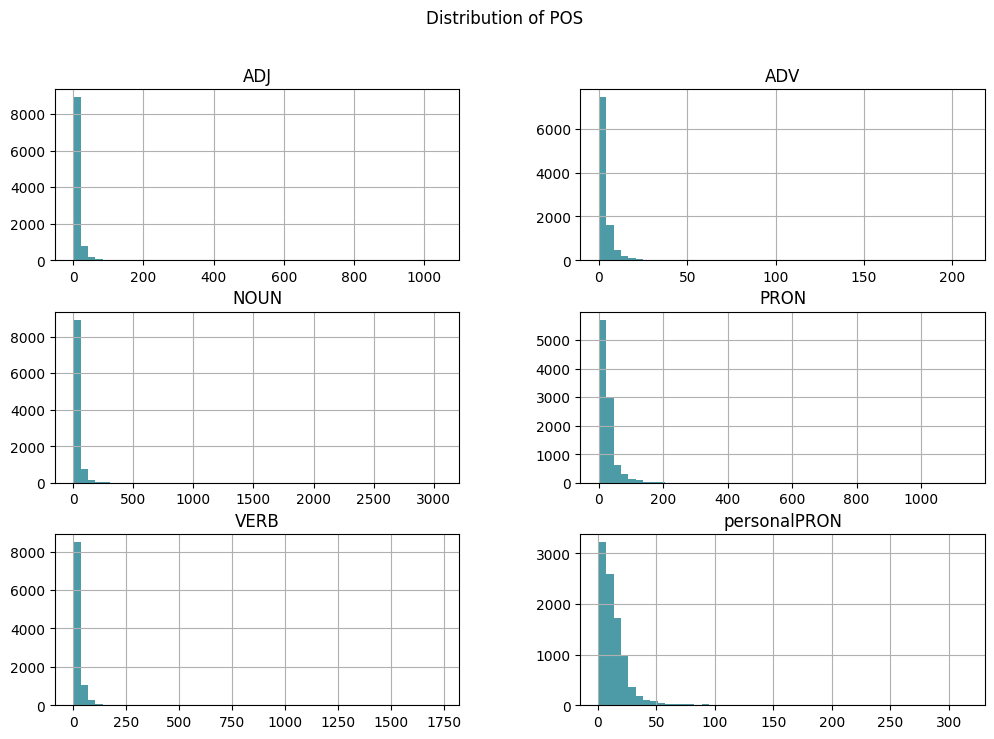

In [16]:

agg_df_depression[pos_cols].hist(figsize=(12, 8), bins=50,color="#4C9BA7")
plt.suptitle("Distribution of POS")
plt.show()



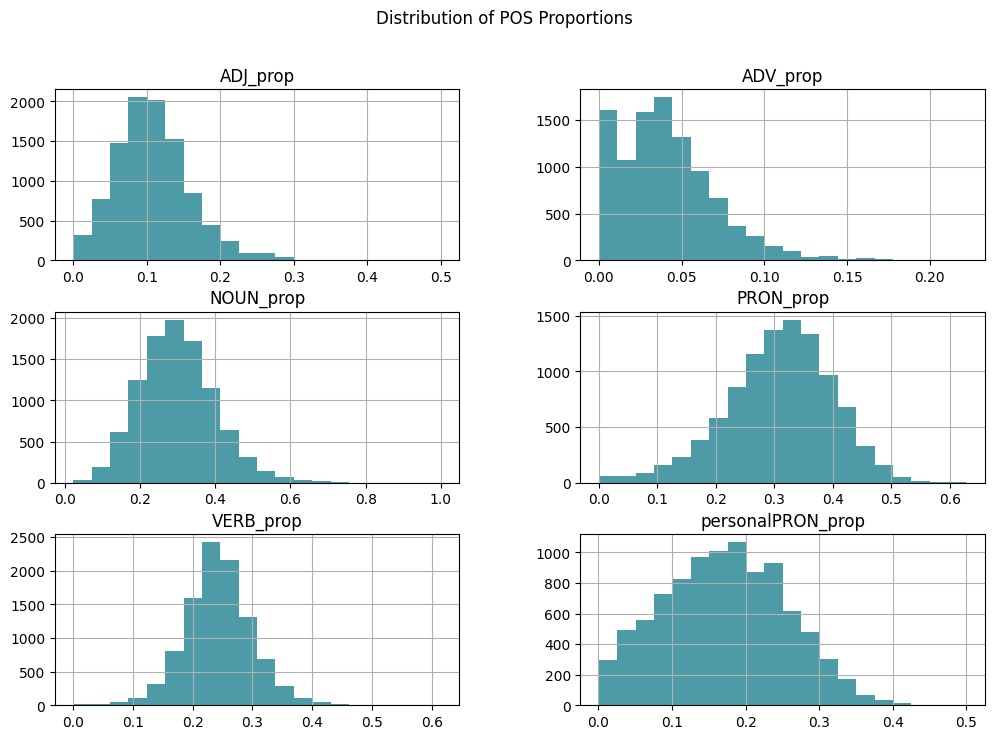

In [17]:
### Normalizacja przez ilość lematów w poście

pos_cols_prop = [col + '_prop' for col in pos_cols]
for col in pos_cols:
    agg_df_depression[col + '_prop'] = agg_df_depression[col] / agg_df_depression['lemma_counts']


agg_df_depression[pos_cols_prop].hist(figsize=(12, 8), bins=20,color="#4C9BA7")
plt.suptitle("Distribution of POS Proportions")
plt.show()

#### Czym różnią się posty osób z depresją od postów na każdy temat?

Przeprowadzamy analizę częstości najpierw patrząc czy średnie mogą nas nakierować na jakieś prawidłowości, a potem eksplorując rozkłady cech zależnie od naszych warunków. Tutaj sprawdzamy różnice w rozkładzie między postów dotyczących depresji vs każdego innego tematu

Tym razem, co pokazaliśmy eksplorując nasz dataset - należy od razu brać poprawkę na ilość lematów w wypowiedzi


In [18]:
# Tworzymy nowe kolumny z proporcjami

agg_df_depression['is_depression'] = agg_df_depression['topic'].apply(lambda x: x if x == "Depression" else "Healthy")
agg_df_depression[pos_cols_prop + ['lemma_counts','is_depression']].groupby(['is_depression']).agg(['mean','std']).transpose()

is_depression           Depression     Healthy
pos                                           
ADJ_prop          mean    0.104840    0.111747
                  std     0.052845    0.051238
ADV_prop          mean    0.042953    0.038476
                  std     0.032305    0.027409
NOUN_prop         mean    0.250152    0.349850
                  std     0.080440    0.095796
PRON_prop         mean    0.348390    0.267688
                  std     0.074468    0.088791
VERB_prop         mean    0.253665    0.232239
                  std     0.057672    0.054444
personalPRON_prop mean    0.211687    0.129896
                  std     0.076211    0.068321
lemma_counts      mean   56.168704  132.009664
                  std    24.386886  196.199553

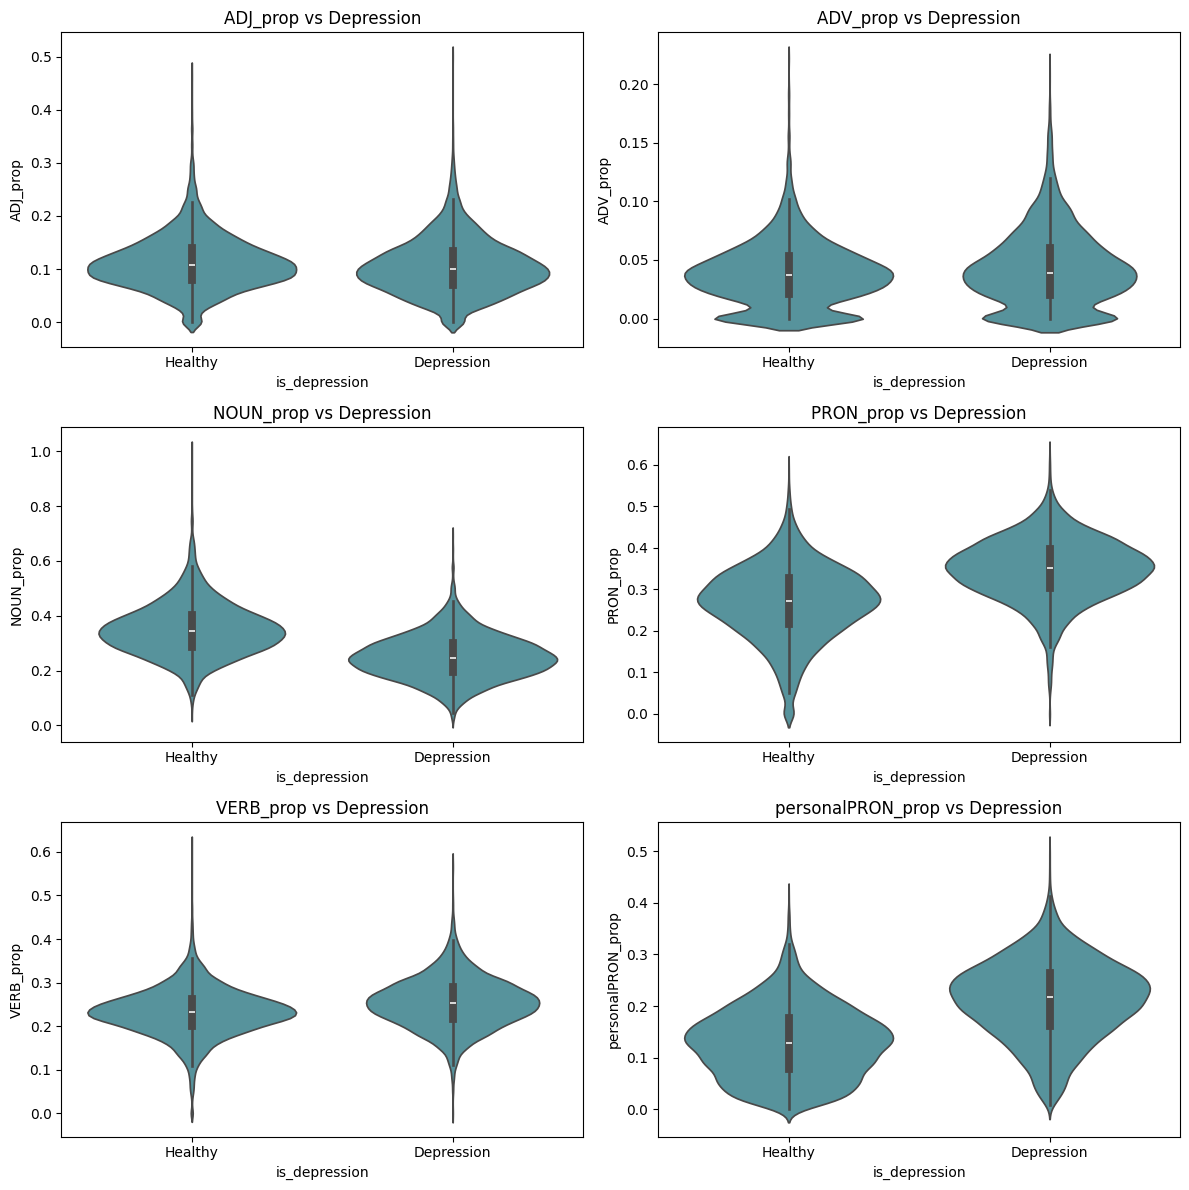

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()  


for i, pos_type in enumerate(pos_cols_prop):
    sns.violinplot(
        x='is_depression',
        y=pos_type,
        data=agg_df_depression[agg_df_depression['lemma_counts'] > 5],
        ax=axes[i],
        color="#4C9BA7"
    )
    axes[i].set_title(f'{pos_type} vs Depression')

for j in range(len(pos_cols_prop), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [20]:
import statsmodels.formula.api as smf

#m1_1 = smf.mixedlm("NOUN ~ is_depression +lemma_counts ", data=agg_df).fit()
model =  smf.ols('PRON ~ is_depression + lemma_counts', data=agg_df_depression[agg_df_depression['lemma_counts'] >5]).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   PRON   R-squared:                       0.852
Model:                            OLS   Adj. R-squared:                  0.852
Method:                 Least Squares   F-statistic:                 2.860e+04
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:20:30   Log-Likelihood:                -40231.
No. Observations:                9958   AIC:                         8.047e+04
Df Residuals:                    9955   BIC:                         8.049e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### Rozkład części mowy: OCEAN

Bardziej skomplikowanym przypadkiem będzie scharakteryzowanie typów osobowości zależnie od ilości użycia poszczególnych części mowy. 
Eseje w tym zbiorze są bardzuej zgodne z metodoloią Weintraub'a: Wczytujemy już preprocesowany dataset w którym każdy wiersz odpowiada jednemu lematowi, wraz z oznaczonym ID, OCEAN, częścią mowy, Osobą, Typem części mowy i czy słowo jest uznawane za Stopwords:



In [ ]:
df_essays_token = pd.read_csv("data/df_essays_token.csv")
print(df_essays['text'].apply(lambda x: len(x.split(" "))).describe())
df_essays_token

count    1578.000000
mean      665.116603
std       260.653586
min        45.000000
25%       483.000000
50%       637.000000
75%       823.000000
max      2653.000000
Name: text, dtype: float64


,Unnamed: 0,post_id,O,C,E,A,N,personality,token,lemma,pos,Number,Person,PronType,is_stop,is_alpha
0,0,0,1,0,0,1,1,19,it,it,PRON,Sing,3.0,Prs,True,True
1,1,0,1,0,0,1,1,19,I,i,PRON,Sing,1.0,Prs,True,True
2,2,0,1,0,0,1,1,19,wait,wait,VERB,NaN,NaN,NaN,False,True
3,3,0,1,0,0,1,1,19,I,i,PRON,Sing,1.0,Prs,True,True
4,4,0,1,0,0,1,1,19,going,go,VERB,NaN,NaN,NaN,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
521922,521922,1577,1,0,1,1,1,23,I,i,PRON,Sing,1.0,Prs,True,True
521923,521923,1577,1,0,1,1,1,23,hope,hope,VERB,NaN,NaN,NaN,False,True
521924,521924,1577,1,0,1,1,1,23,we,we,PRON,Plur,1.0,Prs,True,True
521925,521925,1577,1,0,1,1,1,23,actually,actually,ADV,NaN,NaN,NaN,False,True


           post_id          ADJ          ADV         NOUN         PRON  \
count  1578.000000  1578.000000  1578.000000  1578.000000  1578.000000   
mean    788.500000    32.177440    14.153992    87.882129   116.011407   
std     455.673677    14.891029     7.388897    35.333111    50.846929   
min       0.000000     1.000000     0.000000     4.000000     6.000000   
25%     394.250000    22.000000     9.000000    63.250000    79.000000   
50%     788.500000    30.000000    13.000000    83.000000   109.000000   
75%    1182.750000    40.000000    19.000000   109.000000   145.000000   
max    1577.000000   169.000000    60.000000   294.000000   512.000000   

              VERB  personalPRON  lemma_counts            O            C  \
count  1578.000000   1577.000000   1578.000000  1578.000000  1578.000000   
mean     80.527250     69.213063    330.751584     0.515209     0.508238   
std      34.080468     30.436424    130.927758     0.499927     0.500091   
min       8.000000      2.000

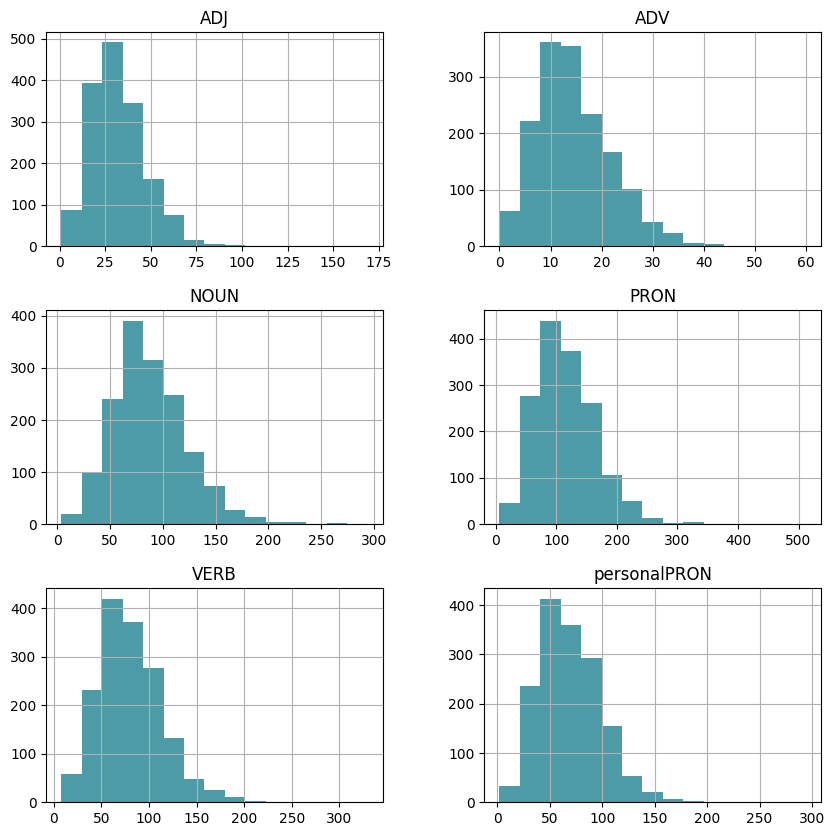

In [22]:
df_essays_token = df_essays_token[['post_id','O','C','E','A','N','personality','token','lemma','pos','Number', 'Person', 'PronType', 'is_stop', 'is_alpha',]]

# Interesujące nas części mowy: Przymiotnik, Przysłówek, Rzeczownik, Zaimek, Czasownik, Zaimek Osobowy
pos_cols = ['ADJ','ADV','NOUN','PRON','VERB','personalPRON']
ocean = ['O','C','E','A','N']

### Częstość części mowy
pos_counts = df_essays_token.groupby('post_id')['pos'].value_counts().unstack(fill_value=0)
pos_counts['personalPRON']  = df_essays_token[
    (df_essays_token['PronType'] == 'Prs') &
    (df_essays_token['Number'] == 'Sing') &
    (df_essays_token['Person'] == 1)
].groupby('post_id').size()

pos_counts['lemma_counts'] = df_essays_token.groupby('post_id')['lemma'].count() # częstość wszystkich lematów

emotions_agg = df_essays_token.groupby('post_id')[['O','C','E','A','N','personality']].max()
agg_df = pos_counts.join(emotions_agg).reset_index()
print(agg_df.describe())


agg_df[pos_cols].hist(figsize=(10,10),bins=15,color="#4C9BA7")
plt.show()


#### Mierzenie rozkładu części mowy zależnie od charakterystyk OCEAN


Możemy teraz zobaczyć, jak zależnie od mieszanki cech OCEAN będą wyglądały rozkłady cech - możey zobacyć, że są one dość podobne! Pamiętajmy jednak, 
że każdy z czynników OCEAN nie jest niezależny, i będą one miały ze sobą interakcję 

Wizualizujemy też od razu częstości normalizowane ze względu na ilość lematów:

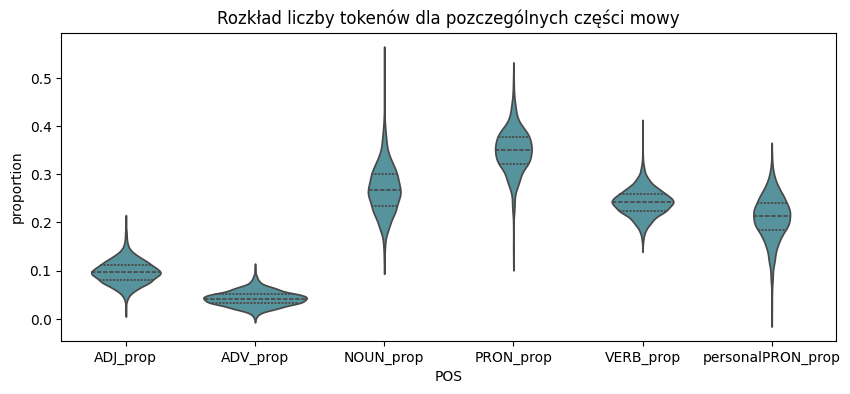

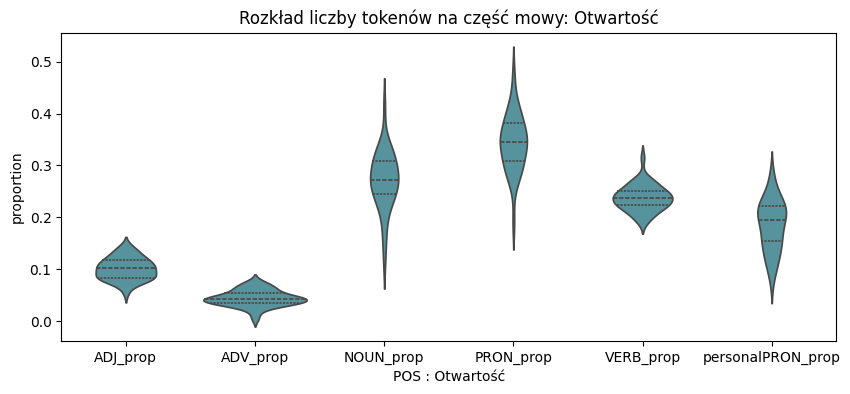

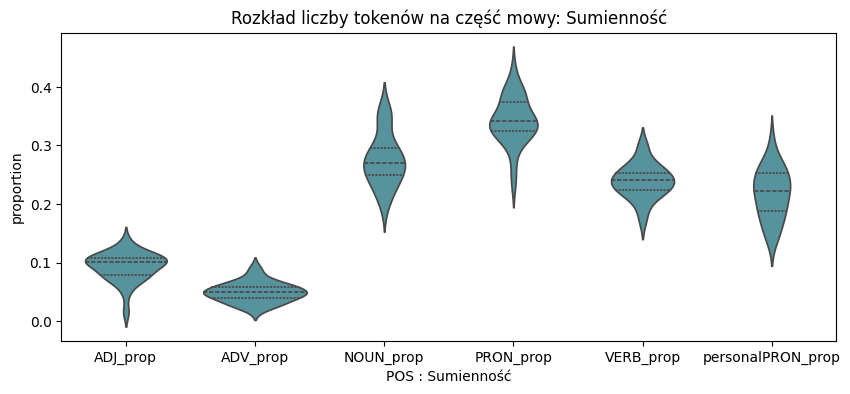

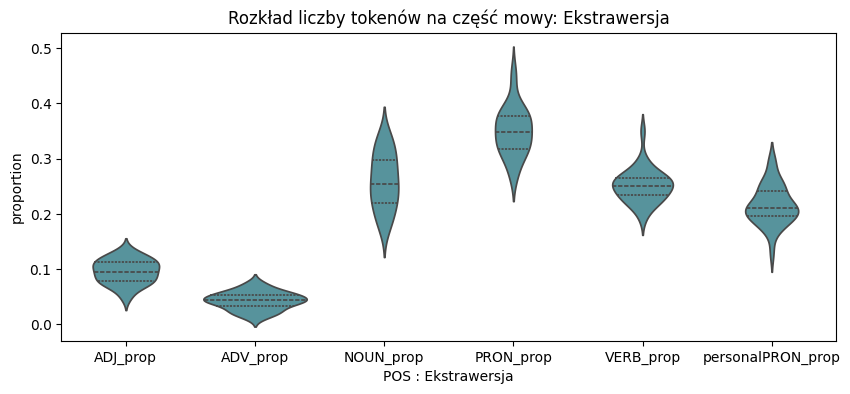

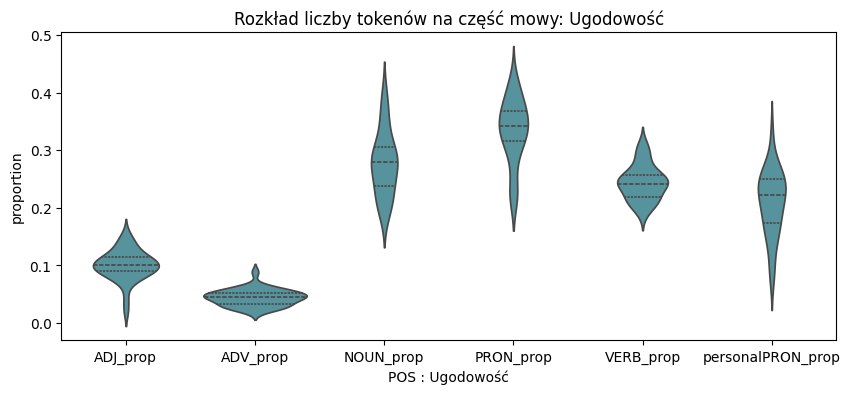

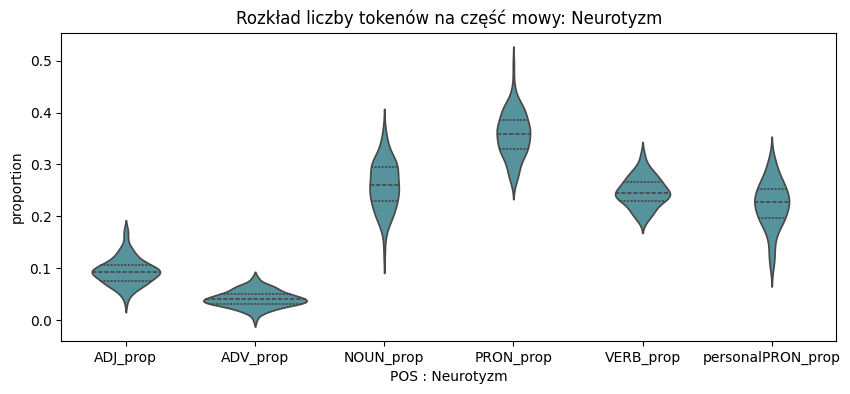

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tworzymy nowe kolumny z proporcjami
for col in pos_cols:
    agg_df[col + '_prop'] = agg_df[col] / agg_df['lemma_counts']

# Ewentualnie melt, żeby zrobić długi format do wizualizacji
pos_long_prop = agg_df.melt(
    id_vars=['post_id','O','C','E','A','N'], 
    value_vars=[c + '_prop' for c in pos_cols],
    var_name='POS',
    value_name='proportion'
)
plt.figure(figsize=(10,4))
sns.violinplot(x='POS', y='proportion', data=pos_long_prop, inner='quartile',color="#4C9BA7")
plt.title('Rozkład liczby tokenów dla pozczególnych części mowy')
plt.show()

contrasts = [(pos_long_prop['O'] == 1) & (pos_long_prop['C'] == 0) & (pos_long_prop['E'] ==0) & (pos_long_prop['A'] ==0) & (pos_long_prop['N'] == 0),
             (pos_long_prop['O'] == 0) & (pos_long_prop['C'] == 1) & (pos_long_prop['E'] ==0) & (pos_long_prop['A'] ==0) & (pos_long_prop['N'] == 0),
             (pos_long_prop['O'] == 0) & (pos_long_prop['C'] == 0) & (pos_long_prop['E'] ==1) & (pos_long_prop['A'] ==0) & (pos_long_prop['N'] == 0),
             (pos_long_prop['O'] == 0) & (pos_long_prop['C'] == 0) & (pos_long_prop['E'] ==0) & (pos_long_prop['A'] ==1) & (pos_long_prop['N'] == 0),
             (pos_long_prop['O'] == 0) & (pos_long_prop['C'] == 0) & (pos_long_prop['E'] ==0) & (pos_long_prop['A'] ==0) & (pos_long_prop['N'] == 1)]
ocean_name = ['Otwartość', 'Sumienność','Ekstrawersja', 'Ugodowość', 'Neurotyzm']
for pos,nam in zip(contrasts,ocean_name):
    plt.figure(figsize=(10,4))
    sns.violinplot(x='POS', y='proportion', data=pos_long_prop[pos &(pos_long_prop['proportion'].isna()==False)], inner='quartile',color="#4C9BA7")
    plt.title(f'Rozkład liczby tokenów na część mowy: {nam}')
    plt.xlabel(f"POS : {nam}")
    plt.show()


#### Porównania częstości

Po eksploracji, możemy się pokusić o sprawdzenie prostych charakterystyk rozkładów które powiedzą nam lepiej czym różni się Wysoka vs Niska wartość cechy OCEAN zależnie od częstości słów

In [24]:
import pandas as pd

traits = ['O','C','E','A','N']

agg_list = []

for trait in traits:
    # grupowanie po jednym trait
    agg_trait = agg_df.groupby(trait)[pos_cols + ['lemma_counts']].agg(['mean','std']).transpose()
    # dodajemy poziom trait jako kolumnę
    agg_trait.columns = pd.MultiIndex.from_product([[trait], agg_trait.columns])
    # zachowujemy wiersze 0 i 1
    agg_list.append(agg_trait)

# łączymy wszystkie w jedną tabelę
agg_combined = pd.concat(agg_list, axis=1)

agg_combined

O                       C                       E  \
                            0           1           0           1           0   
ADJ          mean   30.822222   33.452645   32.094072   32.258105   32.123522   
             std    14.007656   15.578082   14.824919   14.963525   14.276885   
ADV          mean   13.833987   14.455105   13.893041   14.406484   14.240473   
             std     7.315614    7.449139    7.156330    7.603098    7.470380   
NOUN         mean   85.066667   90.531365   87.519330   88.233167   88.513798   
             std    34.018235   36.349264   34.712454   35.941612   35.598679   
PRON         mean  113.904575  117.993850  115.202320  116.794264  115.032852   
             std    47.765407   53.538681   50.876590   50.837690   49.396039   
VERB         mean   78.601307   82.339483   81.018041   80.052369   80.270696   
             std    32.729204   35.228779   34.397182   33.785876   32.527807   
personalPRON mean   69.993464   68.477833   69.021907   69.398252   68.586071   
             std    29.270202   31.496004   31.462474   29.426815   30.324834   
lemma_counts mean  322.228758  338.771218  329.725515  331.744389  330.181340   
             std   124.671143  136.143350  129.935490  131.954219  126.569915   

                                        A                       N              
                            1           0           1           0           1  
ADJ          mean   32.227662   32.354926   32.020311   31.782278   32.573604  
             std    15.449699   14.587557   15.161596   14.821564   14.959273  
ADV          mean   14.073439   14.358974   13.972521   14.011392   14.296954  
             std     7.315843    7.730294    7.072621    7.173470    7.600618  
NOUN         mean   87.293758   88.821862   87.050179   87.679747   88.085025  
             std    35.095519   36.578433   34.193229   35.368564   35.318829  
PRON         mean  116.922889  116.724696  115.379928  111.970886  120.062183  
             std    52.175798   52.172840   49.666317   48.272598   53.025394  
VERB         mean   80.766218   81.672065   79.513740   78.573418   82.486041  
             std    35.483881   35.367899   32.886696   32.800067   35.229703  
personalPRON mean   69.797794   69.230769   69.197368   65.835443   72.603558  
             std    30.547110   31.273025   29.693977   28.359198   32.049586  
lemma_counts mean  331.282742  333.932524  327.935484  324.016456  337.503807  
             std   134.935631  134.089677  128.077851  127.238441  134.266718

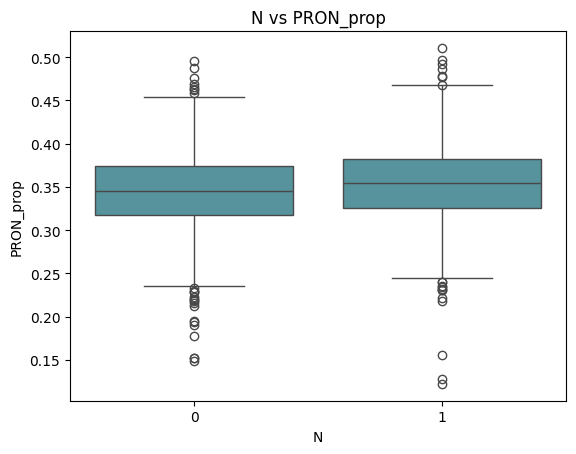

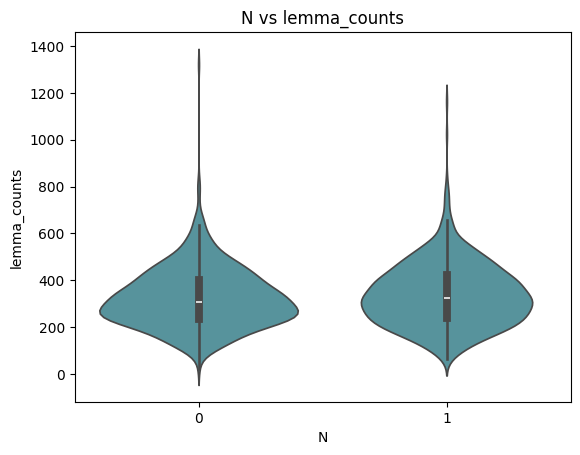

                            OLS Regression Results                            
Dep. Variable:                   PRON   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                     7891.
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:20:41   Log-Likelihood:                -6544.9
No. Observations:                1578   AIC:                         1.310e+04
Df Residuals:                    1575   BIC:                         1.311e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -7.7590      1.101     -7.048   

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf



agg_df['NOUN_div_PRON']=agg_df['NOUN']/agg_df['PRON']
agg_df['VERB_div_NOUN']=agg_df['NOUN']/agg_df['VERB']


POS_type = 'PRON'
PSYCH_type = 'N'

contrasts = [ (agg_df['post_id'] >-1),
              (agg_df['post_id']>-1)]

#contrasts = [ (agg_df['O']== 0),(agg_df['E']== 1)]

# contrasts = [(pos_long_prop['E'] == 1) & (pos_long_prop['N'] == 1),
#              (pos_long_prop['E'] == 0) & (pos_long_prop['N'] == 0)]



# model =  smf.ols('PRON ~ O+ C+E+A+N+lemma_counts', data=agg_df[(agg_df['lemma_counts'] >5)  ]).fit()
# print(model.summary())
sns.boxplot(x=PSYCH_type, y=POS_type+'_prop', data=agg_df[((contrasts[0])| (contrasts[1])) ],color="#4C9BA7")
plt.title(f'{PSYCH_type} vs {POS_type+'_prop'}')
plt.show()

sns.violinplot(x=PSYCH_type, y='lemma_counts', data=agg_df[((contrasts[0])| (contrasts[1])) ],color="#4C9BA7")
plt.title(f'{PSYCH_type} vs lemma_counts')
plt.show()

#m1_1 = smf.mixedlm("NOUN ~ is_depression +lemma_counts ", data=agg_df).fit()
model =  smf.ols(f'{POS_type} ~ {PSYCH_type}+ lemma_counts', data=agg_df[((contrasts[0])| (contrasts[1])) ]).fit()
print(model.summary())



## Analiza Tematów

### Preprocessing

W przypadku analizy tematów, musimy ograniczyć się jedynie do słów niosących znaczenie. Prócz tego, bardziej zaawansowane modele zawierają wymagają kontekstu a nie odsianych lematów. W Związku z tym tworzymy nową ramkę danych ograniczając się jedynie do postów które:

- mają conajmniej 10 lematów
- są w języku angielskim
- lista lematów nie ma zaimków


In [26]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np


emotions = set(sum(df_depression['emotions'], []));

# Definiujemy kolory startowy i końcowy
start_color = "#4C9BA7"
end_color = "#8DD26E"

# Konwersja hex -> RGB (0-1)
start_rgb = np.array(mcolors.to_rgb(start_color))
end_rgb = np.array(mcolors.to_rgb(end_color))

# Tworzymy 100 kroków gradientu
n = 100
gradient = [start_rgb + (end_rgb - start_rgb) * i/(n-1) for i in range(n)]

# Konwersja z powrotem na hex (opcjonalnie)
gradient_hex = [mcolors.to_hex(c) for c in gradient]


In [27]:
from langdetect import detect

df_blog_depression['is_depression'] = df_blog_depression['topic'].apply(lambda x: x if x == "Depression" else "Healthy") # Dodanie Flagi is_depression
df_blog_depression['text'] = df_blog_depression['text'].apply(lambda x: re.sub(r'http\S+|\S+@\S+|urllink', '', x))       # Usunięcie linków, e-maili i wspomnienia o urllink

# tworzenie lsity lematów dla każdego posta, z wykluczeniem zaimków i tokenów które nie są stringami
df_blog_depression_tokens_redux = df_blog_depression_tokens[(df_blog_depression_tokens['pos'] != 'PRON') & (df_blog_depression_tokens['lemma'].apply(type) ==str)].groupby('post_id')['lemma'].apply(list)
df_blog_depression_tokens_redux = df_blog_depression.merge(df_blog_depression_tokens_redux,left_on='id',right_on='post_id')

## Filtrowanie blogpostów które są w języku innm niż angielskie, maja zbyt mało uniklnych lematów (<4) albo są za krótkie znaczeniowo (lematy < 10)

df_blog_depression_tokens_redux = df_blog_depression_tokens_redux[(df_blog_depression_tokens_redux['lemma'].apply(lambda x: len(set(x))) >10) &
                                                                  (df_blog_depression_tokens_redux['lemma'].apply(lambda x: len(set(x))) >4) &
                                                                  (df_blog_depression_tokens_redux['text'].apply(lambda x : detect(x)) == 'en')]

# Łączenie z emocjami
emotions_agg = df_blog_depression_tokens.groupby('post_id')[list(emotions)].max()
df_blog_depression_tokens_redux = df_blog_depression_tokens_redux.merge(emotions_agg,left_on='id',right_index=True)
df_blog_depression_tokens_redux

,Unnamed: 0,id,text,topic,emotions,date_day,date_month,date_year,is_depression,lemma,hopelessness,loneliness,worthlessness,anger,brain dysfunction (forget),emptiness,suicide intent,sadness
0,0,hhcq6e,My mum had a boyfriend when I was around 6 or ...,Depression,"['anger', 'hopelessness', 'sadness']",28,June,2020,Depression,"[mum, boyfriend, meet, volunteer, prison, inca...",True,False,False,True,False,False,False,True
1,1,d0bobn,"Like, I have a ton of friends, I talk to them ...",Depression,"['loneliness', 'sadness', 'emptiness', 'hopele...",6,September,2019,Depression,"[ton, friend, talk, feel, want, actively, seek...",True,True,False,True,False,True,False,True
2,2,wy400i,I’m writing this as I sit on the side of the r...,Depression,"['loneliness', 'hopelessness', 'sadness', 'wor...",26,August,2022,Depression,"[write, sit, road, bridge, busy, highway, carr...",True,True,True,True,False,True,False,True
3,3,crkjga,Feeling unloved can have a huge impact on the ...,Depression,"['loneliness', 'sadness']",17,August,2019,Depression,"[feel, unloved, huge, impact, way, live, speci...",False,True,False,False,False,False,False,True
4,4,zq1lwl,I'm done. I have a bottle of jack danials and ...,Depression,"['emptiness', 'hopelessness']",19,December,2022,Depression,"[bottle, jack, danial, couple, bottle, sleep, ...",True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9953,12072,3571437_6,have you ever felt so stupid sometimes that yo...,Maritime,[],15,June,2004,Healthy,"[feel, stupid, wish, earth, swallow, feel, des...",False,False,False,False,False,False,False,False
9954,12073,3610555_22,"Dull, aching pain has wrought its woe Througho...",Maritime,[],20,July,2004,Healthy,"[dull, ache, pain, work, woe, deed, life, embr...",False,False,False,False,False,False,False,False
9955,12074,3011326_23,Readings Lawrence Lessig has a disenchanting...,Maritime,[],16,March,2004,Healthy,"[reading, disenchant, essay, month, personal, ...",False,False,False,False,False,False,False,False
9956,12075,3571437_24,24 - 25 Jul 2004 Left for Sao Paulo on 24 Sat...,Maritime,[],26,July,2004,Healthy,"[morning, brazilian, send, pick, overslept, th...",False,False,False,False,False,False,False,False


In [28]:
df_blog_depression_tokens_redux.topic.unique()

<ArrowStringArray>
[             'Depression',                  'indUnk',
                 'Student',                    'Arts',
             'Engineering',                'Religion',
            'Architecture',              'Technology',
              'RealEstate',              'Publishing',
    'Communications-Media',               'Education',
                 'Banking',              'Government',
                 'Biotech',              'Non-Profit',
      'Telecommunications',                'Internet',
           'Manufacturing', 'LawEnforcement-Security',
               'Marketing',       'Sports-Recreation',
                     'Law',                'Military',
       'Museums-Libraries',                 'Science',
             'Advertising',              'Consulting',
              'Accounting',        'BusinessServices',
          'HumanResources',          'Transportation',
                 'Fashion',                 'Tourism',
              'Automotive',             'Agric

### Wizualizacje częstości słów

prostym narzędziem wizualizacji i prowadzącym do modelowania tematów jest po prostu zliczenie i zwizualizowanie najczęstszych słów w interesujących nas kategoriach: 

**Word-Cloud** skaluje wielkość wyświetlanych słów zależnie od proporcji danego słowa wzdłuż wypowiedzi. Choc dobre narzędzie wizualizacyjne, analitycznie lepiej zdają egzamin zwykłe wykresy słupkowe

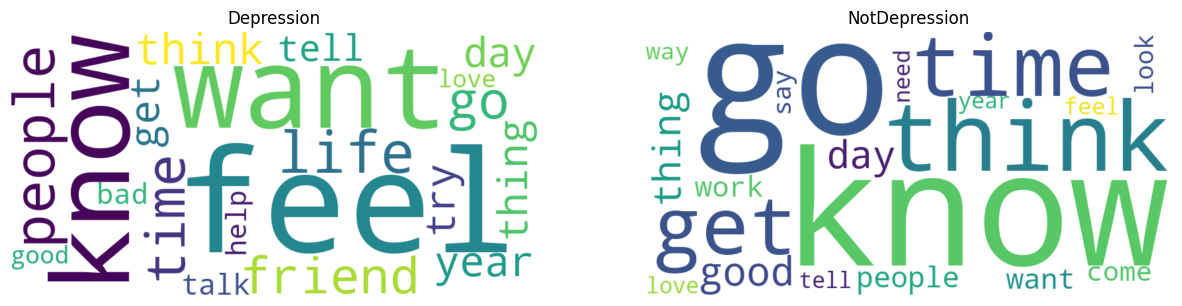

In [29]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


######### Parameters ##################
contrast1 = "Depression"
contrast2 = "NotDepression"
VizWords = 20;
## -------------------------------

freq_dict1 = df_blog_depression_tokens[(df_blog_depression_tokens['pos'] != 'PRON') & (df_blog_depression_tokens["topic"]==contrast1) ] ['lemma'].value_counts().iloc[0:100].to_dict() # Without Personal pronouns
freq_dict2 = df_blog_depression_tokens[(df_blog_depression_tokens['pos'] != 'PRON') & (df_blog_depression_tokens["topic"]!=contrast1) ] ['lemma'].value_counts().iloc[0:100].to_dict() # Without Personal pronouns

nRows1 = len(df_blog_depression_tokens[(df_blog_depression_tokens['pos'] != 'PRON') & (df_blog_depression_tokens["topic"]==contrast1)])
nRows2 = len(df_blog_depression_tokens[(df_blog_depression_tokens['pos'] != 'PRON') & (df_blog_depression_tokens["topic"]!=contrast1) ])


# contrast1 = "Banking"
# contrast2 = "Engineering"

# freq_dict1 = df_blog_depression_tokens[(df_blog_depression_tokens['pos'] != 'PRON') & (df_blog_depression_tokens["topic"]==contrast1) ] ['lemma'].value_counts().iloc[0:100].to_dict() # Without Personal pronouns
# freq_dict2 = df_blog_depression_tokens[(df_blog_depression_tokens['pos'] != 'PRON') & (df_blog_depression_tokens["topic"]==contrast2) ] ['lemma'].value_counts().iloc[0:100].to_dict() # Without Personal pronouns

# nRows1 = len(df_blog_depression_tokens[(df_blog_depression_tokens['pos'] != 'PRON') & (df_blog_depression_tokens["topic"]==contrast1)])
# nRows2 = len(df_blog_depression_tokens[(df_blog_depression_tokens['pos'] != 'PRON') & (df_blog_depression_tokens["topic"]==contrast2) ])


# Tworzymy WordCloud
wc1 = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=VizWords
).generate_from_frequencies(freq_dict1)

wc2 = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=VizWords
).generate_from_frequencies(freq_dict2)

fig, axs = plt.subplots(1, 2,figsize=(15, 15))


axs[0].imshow(wc1, interpolation='bilinear')
axs[0].axis('off')
axs[0].set_title(contrast1)

axs[1].imshow(wc2, interpolation='bilinear')
axs[1].axis('off')
axs[1].set_title(contrast2)

plt.show()

Możemy zwizualizować Słowa Podobne i Niepodobne między naszymi kategoriami. Pozwoli to na oszacowanie czym różnią się nasze dwie kategorie pod względem słów zawartych

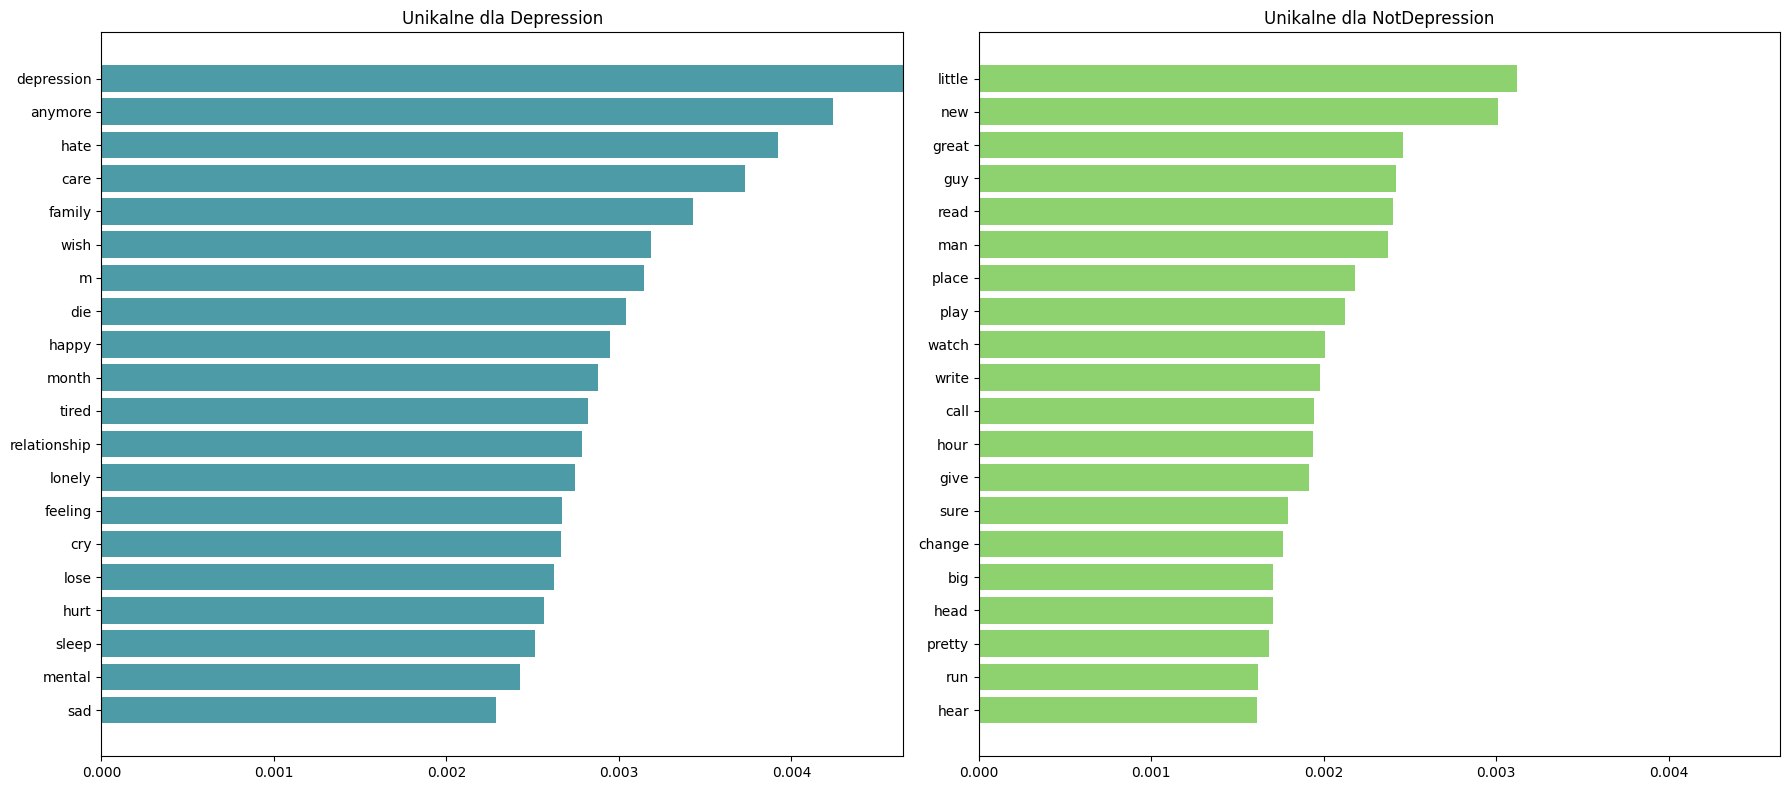

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Klucze unikalne
only_1 = freq_dict1.keys() - freq_dict2.keys() 
only_2 = freq_dict2.keys() - freq_dict1.keys()

# 2. Normalizacja + sortowanie, ograniczenie do VizWords
top1 = dict(sorted(
    {k: freq_dict1[k]/nRows1 for k in only_1}.items(),
    key=lambda x: x[1],
    reverse=True
)[:VizWords])

top2 = dict(sorted(
    {k: freq_dict2[k]/nRows2 for k in only_2}.items(),
    key=lambda x: x[1],
    reverse=True
)[:VizWords])

# 3. Dane do wykresu
keys1, values1 = list(top1.keys()), list(top1.values())
keys2, values2 = list(top2.keys()), list(top2.values())

# 4. Wspólna skala x
max_val = max(max(values1), max(values2))

# 5. Kolory
color1 = '#4C9BA7'
color2 = "#8DD26E"

# 6. Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# subplot 1
axes[0].barh(keys1, values1, color=color1)
axes[0].set_xlim(0, max_val)
axes[0].set_title(f'Unikalne dla {contrast1}')
axes[0].invert_yaxis()

# subplot 2
axes[1].barh(keys2, values2, color=color2)
axes[1].set_xlim(0, max_val)
axes[1].set_title(f'Unikalne dla {contrast2}')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Eksploracja Kategorii: Empath

Bardziej wyrafinowanym zliczaniem częstości będzie spojrzenie na ilości słów zakwalifikowanych do poszczególnych kategorii. Istnieje specjalne oprogramowanie dedykowane dla psychologów pozwalające na prostą analizę częstości znaczeń: **LIWC** - *Linguistic Inquiry and Word Count*. Niestety program jest płatny

W Python mamy darmową alternatywę umożliwiającą nam tworzenie naszych własnych kategorii, analizę częstości - **Empath**. Działa ona według tej samej zasady zliczania jednostek leksykalnych należących do wybranej kategorii: 





In [31]:
from empath import Empath
lexicon = Empath()


### Stworzenie emocjonalnych kategorii
lexicon.create_category("self-hatred", ["self-hatred"], model="reddit")
lexicon.create_category('apathy', ['apathy'], model="reddit")
lexicon.create_category('depression', ['depression'], model="reddit")
lexicon.cats['anger'] = [ w.replace("_"," ") for w in lexicon.cats['anger'] ]
lexicon.cats['self-hatred'] = [ w.replace("_"," ") for w in lexicon.cats['anger'] ]
lexicon.cats['apathy'] = [ w.replace("_"," ") for w in lexicon.cats['anger'] ]
lexicon.cats['depression'] = [ w.replace("_"," ") for w in lexicon.cats['anger'] ]


["self-hatred", "self-loathing", "self_loathing", "self-hate", "self_hatred", "self_hate", "self_doubt", "worthlessness", "loneliness", "self-doubt", "self-pity", "hopelessness", "inadequacy", "insecurity", "powerlessness", "negative_emotions", "helplessness", "low_self-esteem", "poor_self-esteem", "neurosis", "negative_feelings", "coping_mechanism", "own_depression", "intense_feelings", "self-sabotage", "overwhelming_feelings", "negative_thinking", "low_self_esteem", "sadness", "emotional_pain", "lonliness", "depression", "narcissism", "negative_emotion", "loathing", "self-blame", "shitty_feelings", "irrational_thoughts", "sexual_frustration", "misanthropy", "self-centeredness", "anxieties", "social_isolation", "other_feelings", "self-esteem_issues", "suicidal_depression", "anger", "self-love", "self_consciousness", "horrible_feelings", "jealousy", "self_sabotage", "self-criticism", "resentment", "victim_mentality", "crippling_depression", "destructive_thoughts", "existential_angst", 

In [32]:

texts = df_blog_depression_tokens_redux['lemma'].apply(lambda x: " ".join(x))

analysis = lexicon.analyze(texts.iloc[0],normalize=True)
result = {k: [] for k in analysis.keys()}

### Pętla generujące dla każego tekstu oszacowanie wystąpienia każdej z kategorii
for i,txt in enumerate(texts):
    analysis = lexicon.analyze(txt,normalize=False)
     
    for k in result:
        result[k].append(analysis.get(k, 0))
    
EmpathyTopics = pd.DataFrame(result)

In [33]:
EmpathyTopics

,help,office,dance,money,wedding,domestic_work,sleep,medical_emergency,cold,hate,...,contentment,writing,rural,positive_emotion,musical,apathy,depression,loneliness,self-hatred,suicide
0,1.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0,0.0,...,2.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9953,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,3.0,2.0,...,4.0,3.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0
9954,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
9955,0.0,2.0,4.0,3.0,12.0,0.0,0.0,0.0,0.0,1.0,...,0.0,3.0,1.0,3.0,6.0,0.0,0.0,0.0,0.0,0.0
9956,6.0,0.0,7.0,5.0,1.0,2.0,10.0,1.0,1.0,1.0,...,0.0,0.0,3.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0


In [34]:
df_depression

,Unnamed: 0,id,text,topic,emotions,date_day,date_month,date_year
0,0,hhcq6e,My mum had a boyfriend when I was around 6 or ...,Depression,"[anger, hopelessness, sadness]",28,June,2020
1,1,d0bobn,"Like, I have a ton of friends, I talk to them ...",Depression,"[loneliness, sadness, emptiness, hopelessness,...",6,September,2019
2,2,wy400i,I’m writing this as I sit on the side of the r...,Depression,"[loneliness, hopelessness, sadness, worthlessn...",26,August,2022
3,3,crkjga,Feeling unloved can have a huge impact on the ...,Depression,"[loneliness, sadness]",17,August,2019
4,4,zq1lwl,I'm done. I have a bottle of jack danials and ...,Depression,"[emptiness, hopelessness]",19,December,2022
...,...,...,...,...,...,...,...,...
6032,6032,no1lxs,As someone who is trying their hardest to reco...,Depression,"[brain dysfunction (forget), anger, sadness, h...",30,May,2021
6033,6033,dlvwq7,Hi over the last year my friends have started ...,Depression,"[loneliness, hopelessness, emptiness, sadness]",23,October,2019
6034,6034,17ap454,I'm a trans girl and that's why everything is ...,Depression,"[loneliness, hopelessness, sadness, emptiness,...",18,October,2023
6035,6035,moqihl,Good luck watering the Sahara desert and expec...,Depression,"[hopelessness, anger, sadness]",11,April,2021


In [35]:
topic_empathy ='worthlessness'

print(f"Kluczowe konteksty tematyczne dla: {topic_empathy}")
EmpathyTopics[df_blog_depression_tokens_redux[topic_empathy].to_list()].mean().sort_values(ascending=False).head(10)


Kluczowe konteksty tematyczne dla: worthlessness


negative_emotion    2.696602
pain                2.279935
violence            2.155744
shame               2.066343
sadness             1.784790
positive_emotion    1.658172
love                1.557039
nervousness         1.523867
suffering           1.344256
body                1.335761
dtype: float64

Możemy następnie eksplorować znowu jakimi kategoriami różnią się posty depresyjne od nie depresyjnych.

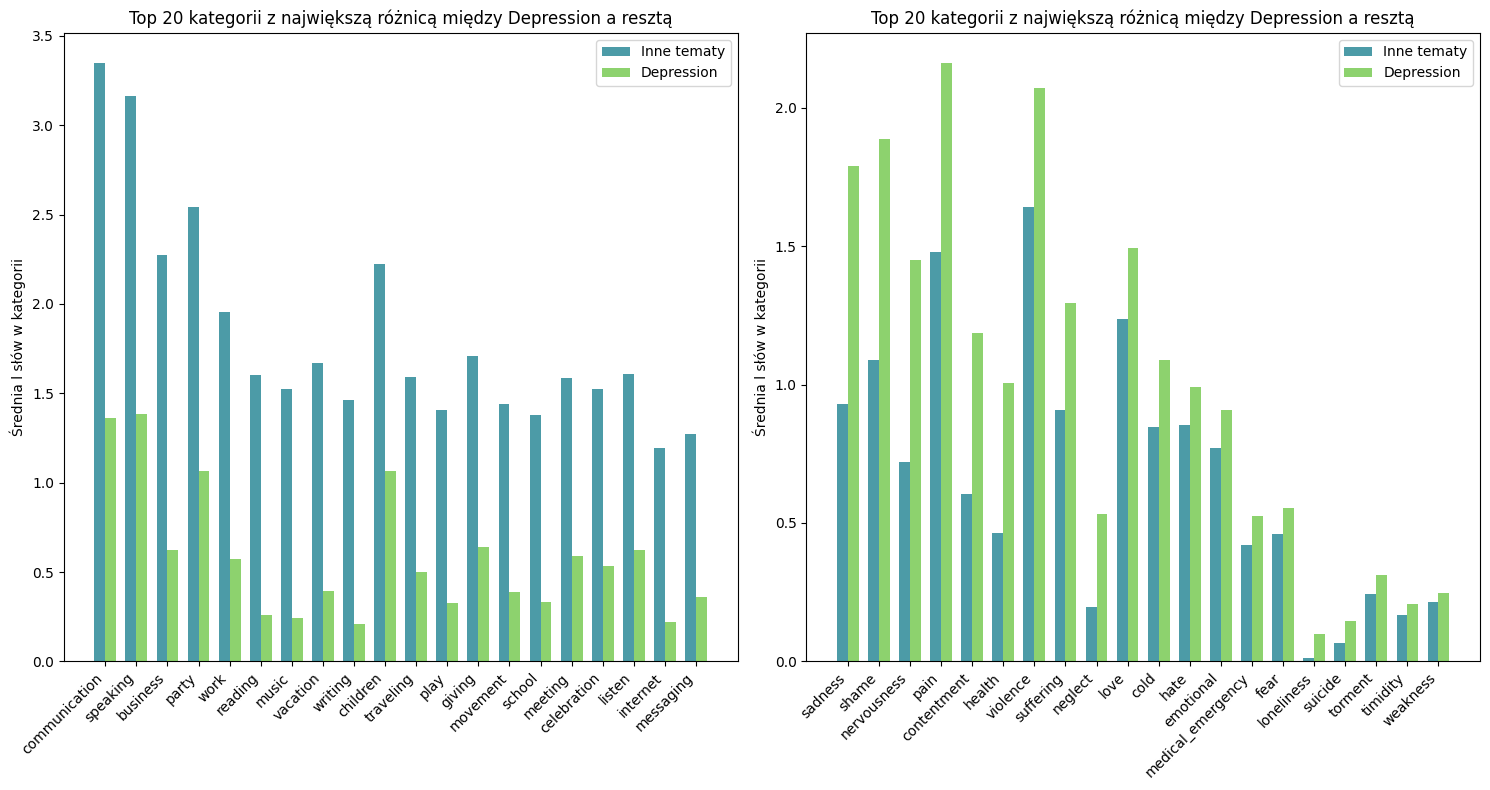

In [37]:
temat = 'Depression' #
VizWords       = 20

contrast1 = EmpathyTopics[(df_blog_depression_tokens_redux['topic'] !=temat).to_list()].mean().sort_values(ascending=False)
contrast2 = EmpathyTopics[(df_blog_depression_tokens_redux['topic'] ==temat).to_list()].mean().sort_values(ascending=False)


fig, ax = plt.subplots(1,2,figsize=(15,8))

for i,diffs in enumerate([ contrast1-contrast2, contrast2-contrast1]):
    diffsTop = diffs.sort_values(ascending=False).head(VizWords)

    keys = diffsTop.index.tolist()
    values_dep = contrast2[keys].values
    values_other = contrast1[keys].values

    x = np.arange(len(keys))
    max_val = max(max(values_dep), max(values_other))


    ax[i].bar(x -  0.35/2, values_other,  0.35, label='Inne tematy', color=color1)
    ax[i].bar(x +  0.35/2, values_dep,  0.35, label=temat, color=color2)

    ax[i].set_xticks(x)
    ax[i].set_xticklabels(keys, rotation=45, ha='right')
    ax[i].set_ylabel('Średnia l słów w kategorii')
    ax[i].set_title(f'Top {VizWords} kategorii z największą różnicą między {temat} a resztą')
    ax[i].set_ylim(0, max_val*1.05)
    ax[i].legend()
plt.tight_layout()
plt.show()

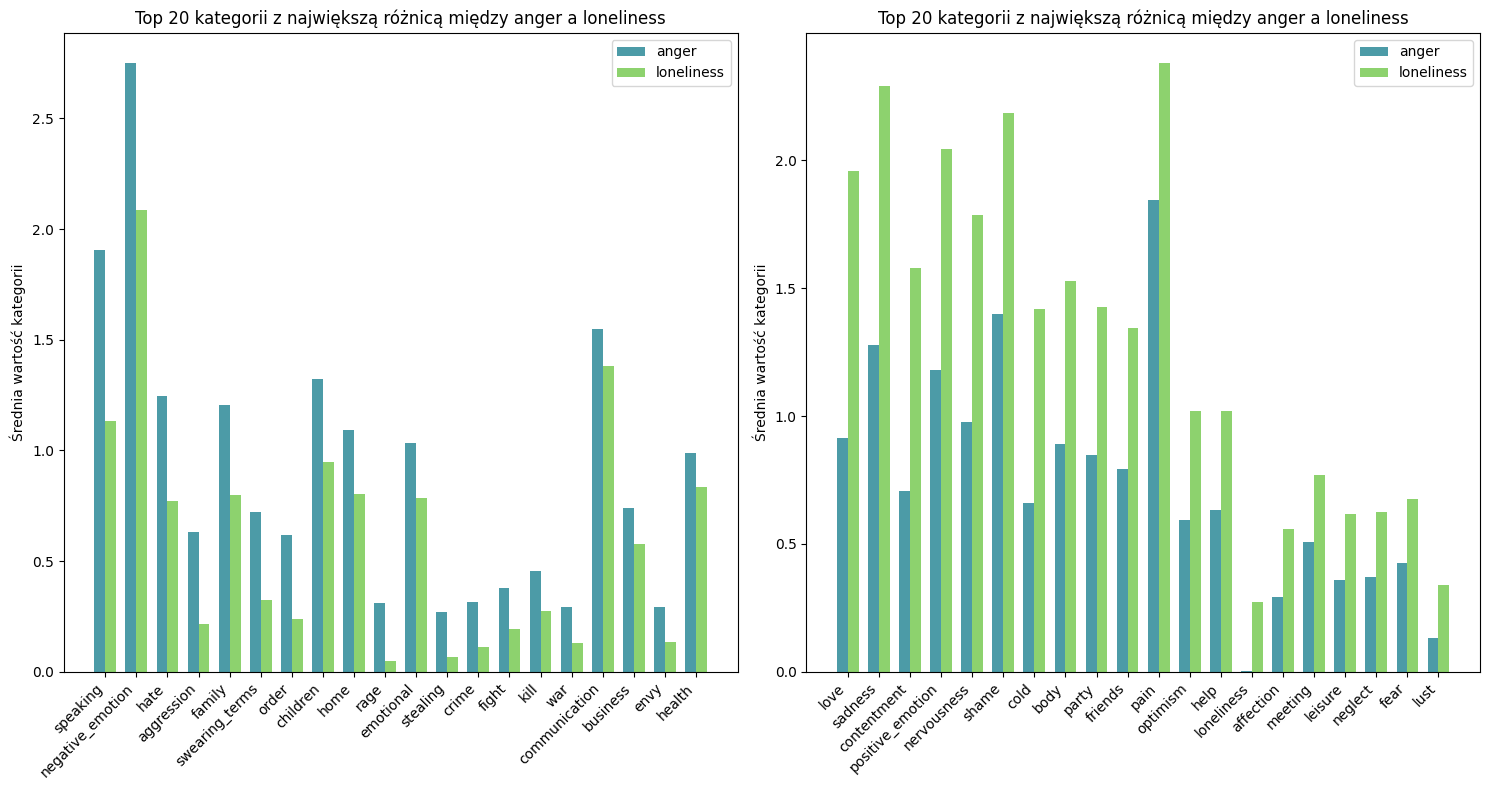

In [38]:


emocje_1 = "anger"
emocje_2 = "loneliness"
VizWords       = 20

contrast1  = EmpathyTopics[((df_blog_depression_tokens_redux['topic'] == "Depression" )& (df_blog_depression_tokens_redux[emocje_1] )& (df_blog_depression_tokens_redux[emocje_2] != True)).to_list()].mean().sort_values(ascending=False)
contrast2 = EmpathyTopics[((df_blog_depression_tokens_redux['topic'] == "Depression" )& (df_blog_depression_tokens_redux[emocje_2] )& (df_blog_depression_tokens_redux[emocje_1] != True)).to_list()].mean().sort_values(ascending=False)


fig, ax = plt.subplots(1,2,figsize=(15,8))

for i,diffs in enumerate([ contrast1-contrast2, contrast2-contrast1]):
    diffsTop = diffs.sort_values(ascending=False).head(VizWords)

    keys = diffsTop.index.tolist()
    values_dep = contrast2[keys].values
    values_other = contrast1[keys].values

    x = np.arange(len(keys))
    max_val = max(max(values_dep), max(values_other))


    ax[i].bar(x -  0.35/2, values_other,  0.35, label=emocje_1, color=color1)
    ax[i].bar(x +  0.35/2, values_dep,  0.35, label=emocje_2, color=color2)

    ax[i].set_xticks(x)
    ax[i].set_xticklabels(keys, rotation=45, ha='right')
    ax[i].set_ylabel('Średnia wartość kategorii')
    ax[i].set_title(f'Top {VizWords} kategorii z największą różnicą między {emocje_1} a {emocje_2}')
    ax[i].set_ylim(0, max_val*1.05)
    ax[i].legend()
plt.tight_layout()
plt.show()

## Analiza LDA:

To jedna z pierwszych, probabilistycznych nienadzorowanych metod modelowania tematów.
Opiera się na modelu zakładającym, że procesowane przez nas teksty powstały jako zbiór słów przynależnych do ograniczonej liczby tematów

Następnie metody numeryczne estymują parametry rozkładu słów i tym samym ich przynależność. Poniższy obrazek reprezentuje w uproszczony sposób działanie zalożeń generacyjnych: 
1. Najpierw z puli klas rozłożonych według rozkładu wielu zmiennych dobieramy wybraną klasę
2. Następnie dla każdego tematu z rozkładu słów wybieramy najbardziej prawdopodobne słowo 
3. Zapisujemy do dokumentu i powtarzamy N razy - dostając dokument będący rezultatem wielokrotnego losowania a rozkładzie tematów i słów

![image.jpeg](./data/1fCc0JT3W-1ViYyw0hJ7rdA.jpeg)


Działając z algorytmem LDA musimy najpierw uporządkować naszą przestrzeń słów. Podobnie jak w przypadku analiz częstości, musimy zlematyzować przestrzeń aby dostać łatwo identyfikowalne jednostki. Następnie kodujemy każde słowo w dokumencie nadając mu arbitralny identyfikator, tworząc tzw. **leksykon**

Możemy na tym etapie odsiać zbyt częste lub zbyt rzadkie słowa, aby pozbyć się niereguralności oraz nawyków językowych. Taki sposób kodowania słów nazywa się **bag of words**

#### LDA identyfikujące tematy w postach depresyjnych

In [39]:

from gensim import corpora

# df_topic['lemmas'] = lista lematów per post
texts = df_blog_depression_tokens[(df_blog_depression_tokens['pos'] != 'PRON') &( df_blog_depression_tokens['topic'] == "Depression")].groupby('post_id')['lemma'].apply(list)
goodStoriesID = texts.index
docs = texts.to_list()

# Tworzymy leksykon
dictionary = corpora.Dictionary(docs)
# Filtrowanie bardzo rzadkich i bardzo częstych słów
dictionary.filter_extremes(no_below=2, no_above=0.95)

# Corpus: lista (word_id, count) dla każdego dokumentu
corpus = [dictionary.doc2bow(text) for text in texts]
dictionary.token2id

{'angry': 0,
 'bad': 1,
 'comfortable': 2,
 'day': 3,
 'depression': 4,
 'describe': 5,
 'different': 6,
 'eggshell': 7,
 'end': 8,
 'fear': 9,
 'feel': 10,
 'feeling': 11,
 'fuck': 12,
 'get': 13,
 'give': 14,
 'gut': 15,
 'help': 16,
 'hurt': 17,
 'justification': 18,
 'listen': 19,
 'person': 20,
 'ridiculous': 21,
 'say': 22,
 'scary': 23,
 'shout': 24,
 'snap': 25,
 'tell': 26,
 'terrified': 27,
 'thing': 28,
 'try': 29,
 'turn': 30,
 'violent': 31,
 'walk': 32,
 'way': 33,
 'cat': 34,
 'family': 35,
 'good': 36,
 'learn': 37,
 'right': 38,
 'sad': 39,
 'short': 40,
 'surf': 41,
 'think': 42,
 'travel': 43,
 'truly': 44,
 'unbearably': 45,
 'wish': 46,
 'ago': 47,
 'completely': 48,
 'enjoy': 49,
 'explanation': 50,
 'false': 51,
 'go': 52,
 'hate': 53,
 'hear': 54,
 'life': 55,
 'literally': 56,
 'people': 57,
 'positivity': 58,
 'sick': 59,
 'specific': 60,
 'suck': 61,
 'want': 62,
 'well': 63,
 'year': 64,
 'barely': 65,
 'bored': 66,
 'drink': 67,
 'energy': 68,
 'have': 69,


In [40]:
from gensim.models import LdaModel


n_topics = 8  # liczba tematów
lda_model = LdaModel(corpus=corpus,       # Corpus - zbiór dokumentów w formie bag-of-words
                     id2word=dictionary,  # Leksykon
                     num_topics=n_topics, # Liczba tematów
                     random_state=42,
                     passes=10,
                     alpha='auto', # rozkład tematów w dokumencie którego się spodziewamy 
                     eta = "auto", # rozkład słów w tematach 
                     per_word_topics=True)# Zwraca dla każdego słowa prawdopodobieństwo tematów 




Możemy następnie zwizualizować słowa charakterystyczne dla tematów, oraz nadać każdemu dokumentowi prawdopodobieństwo poszczególnego tematu

In [41]:
topic_labels = {}
for topic_id, topic_words in lda_model.show_topics(num_topics=n_topics, num_words=10, formatted=False):
    words = [w for w,p in topic_words]
    # np. label = słowo o największym prawdopodobieństwie lub top 2-3 słowa
    topic_labels['topic_'+str(topic_id)] = ','.join(words[:10])

    print(f"Topic {topic_id}: "+topic_labels['topic_'+str(topic_id)])

Topic 0: life,live,look,year,fuck,people,fucking,die,hate,work
Topic 1: day,feel,sleep,bad,go,wake,work,time,want,thing
Topic 2: people,miss,know,hurt,friend,love,message,leave,go,lot
Topic 3: want,know,abuse,go,parent,life,child,hate,kid,divorce
Topic 4: tell,get,say,year,know,go,help,depression,month,time
Topic 5: feel,want,know,people,life,time,think,try,love,thing
Topic 6: friend,feel,people,talk,year,time,go,get,life,want
Topic 7: post,time,woman,date,say,look,divorce,police,man,like


In [42]:

corpdoc_topics = [lda_model.get_document_topics(bow, minimum_probability=0) for bow in corpus]

import pandas as pd


# funkcja, która tworzy słownik dla danego dokumentu
def extract_topics(doc, topics=range(0,n_topics)):
    topic_dict = {}
    for t_id, prob in doc:
        if t_id in topics:
            topic_dict[f"topic_{t_id}"] = prob
    return topic_dict

# mapujemy po wszystkich dokumentach
rows = [extract_topics(doc) for doc in corpdoc_topics]

# tworzymy DataFrame
df_topics_selected = pd.DataFrame(rows)
df_topics_selected

,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7
0,0.001940,0.218711,0.001613,0.002669,0.494673,0.274640,0.004310,0.001443
1,0.108657,0.006907,0.004063,0.006720,0.009589,0.849543,0.010888,0.003634
2,0.003195,0.004519,0.002657,0.004395,0.006293,0.969441,0.007122,0.002377
3,0.004311,0.551682,0.003585,0.005930,0.008464,0.038569,0.384253,0.003207
4,0.001420,0.097592,0.041616,0.001953,0.002791,0.745710,0.107861,0.001056
...,...,...,...,...,...,...,...,...
4986,0.003340,0.324748,0.002777,0.004594,0.006564,0.648092,0.007400,0.002484
4987,0.404781,0.005463,0.003212,0.005311,0.007591,0.029310,0.541459,0.002873
4988,0.002538,0.003589,0.002111,0.003491,0.343876,0.636873,0.005635,0.001888
4989,0.005225,0.108647,0.004345,0.007187,0.010285,0.848767,0.011658,0.003886


In [43]:

main_topic = 'topic_1'
  
top10 = df_topics_selected.nlargest(10, main_topic).index


import textwrap
print(f"=== {main_topic}: {topic_labels[main_topic]} ====\n")

for i in top10:
    print()
    print(textwrap.fill( df_blog_depression_tokens_redux[(df_blog_depression_tokens_redux['topic'] == "Depression" )]['text'].iloc[i], width=100)) #text is the object which you want to print
    print(df_topics_selected.iloc[i])

=== topic_1: day,feel,sleep,bad,go,wake,work,time,want,thing ====


I have been severely depressed last few weeks while I have always been able to cope with depressive
episodes without informing my husband but this has gotten worse and I dont have any family locally
to rely on except him. He refuses to help me or support me saying it's too much for him to handle.
This triggers my depression even more. Not sure what I should do or how I get myself out of it?
Therapy isn't a option as it costs a lot.
topic_0    0.001040
topic_1    0.978252
topic_2    0.000865
topic_3    0.001431
topic_4    0.002050
topic_5    0.013275
topic_6    0.002313
topic_7    0.000774
Name: 1002, dtype: float32

I live alone, and havent been back home to my place of birth for years and year. I understand
loneliness, and am happy to lend a listening ear.  &#x200B;  find out more at my website
[talktoanobody.com]( . Not sexual or criminal, just listening services, free of charge, where you
can vent on anything you wa

### BERTopic

Poprzednie metody miały ograniczoną użyteczność z powodu oparcia o częstościach słów, nie bacząc na semantykę

Model BERTopic jest oparty o wektoryzacji **BERT embedding** aby zaprezentować każy tekst w przestrzeni semantycznej - w której jest następnie przeprowadzana klasteryzacja. Opiera się on w dużej mierze o model językowy BERT - korzystający z warstwy Transformerów, aby uczyć się znaczeń przez znajdowanie szerokich powiązań i współwystępowań na dużym korpusie językowym



In [69]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

topic_model = BERTopic()


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9091.38it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [70]:
topics, probs = topic_model.fit_transform(df_blog_depression_tokens_redux[df_blog_depression_tokens_redux['topic']=="Depression"]['text'])
topic_model.get_topic_info().head(20)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10110.54it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2624,-1_to_and_my_the,"[to, and, my, the, im, of, me, it, just, have]",[I’m honestly just tired of life. I wish for o...
1,0,347,0_he_him_his_hes,"[he, him, his, hes, and, to, me, we, for, but]",[So earlier this month my husband left me for ...
2,1,130,1_suicide_kill_die_to,"[suicide, kill, die, to, it, myself, want, jus...",[I don't want to kill myself I just want to pa...
3,2,124,2_divorce_she_the_you,"[divorce, she, the, you, her, wife, was, marri...",[I just wanted to come back and talk about lif...
4,3,115,3_loneliness_lonely_you_to,"[loneliness, lonely, you, to, people, is, be, ...",[Loneliness is when nobody is sad to see you l...
5,4,94,4_she_her_and_we,"[she, her, and, we, shes, me, to, for, with, is]",[My girlfriend and I have been together 3 year...
6,5,90,5_friends_they_friend_them,"[friends, they, friend, them, to, one, people,...",[My friend or well ‘ex friend’ sent me this\n\...
7,6,82,6_ptsd_trauma_that_the,"[ptsd, trauma, that, the, people, it, my, have...",[I brought up that I think I have PTSD from my...
8,7,80,7_she_her_mom_me,"[she, her, mom, me, shes, my, and, to, mother,...",[My mother isn't always a bad. She can be nice...
9,8,79,8_depression_feel_like_just,"[depression, feel, like, just, to, but, depres...",[I feel so lonely because I've never found any...


In [71]:
topic_id =4;

repr_docs = topic_model.get_topic_info().iloc[topic_id]['Representative_Docs']
print(f" Topic: {topic_model.get_topic_info().iloc[topic_id]['Topic']}")
print(f" Representation docs: {topic_model.get_topic_info().iloc[topic_id]['Representation']}\n")
for tops in repr_docs:

    print(textwrap.fill(tops))
    print()

 Topic: 3
 Representation docs: ['loneliness', 'lonely', 'you', 'to', 'people', 'is', 'be', 'the', 'it', 'of']

Loneliness is when nobody is sad to see you leave. Loneliness is when
nobody is disappointed when you're not there, or even care at all.
Loneliness is when you walk behind on the sidewalk, or nobody waits
for you. Loneliness is when you're in a group and you try to talk but
no one acknowledges you or even looks at you. Loneliness is when
people treat you differently because they can tell there is something
wrong with you. They give you a look of pity, indifference, disgust or
smug arrogance. Loneliness is having no one to love you when you feel
down, no one to support you when you're struggling, no one to help you
up when you fall, and no one to encourage you when you feel
discouraged. Loneliness is feeling completely and totally useless and
unlovable because you are alone when near everyone else is surrounded
by people who care for them. Total isolation is a pain incompatibl

Mozemy zredukować ilość naszych tematów przez zmienną **reduce topics**

In [50]:
import copy
topic_model_red = copy.deepcopy(topic_model)

topic_model_red.reduce_topics(df_blog_depression_tokens_redux[df_blog_depression_tokens_redux['topic']=="Depression"]['text'], nr_topics=5)
topic_model_red.get_topic_info().head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2617,-1_to_and_the_my,"[to, and, the, my, me, of, im, it, that, just]",[I've been burned with a cigarette before. I'v...
1,0,1498,0_to_and_the_my,"[to, and, the, my, of, it, im, me, that, in]",[I don’t know about other people but for me th...
2,1,755,1_and_to_he_the,"[and, to, he, the, my, me, him, she, for, it]",[We’ve had two weeks of okay and good days and...
3,2,76,2_the_to_and_of,"[the, to, and, of, that, this, is, for, in, it]","[To set it up, I'm a Black male and my wife is..."
4,3,45,3_to_my_and_eat,"[to, my, and, eat, the, it, is, of, have, im]",[so my mom has been judging me for it and has ...


#### BERTopic - model szczegółowy

Poprzedni model ma dużo poza znaczeniowych elementów. Prócz tego klastry które zostały nam zwrócone nie wydają się rozsądne... Spróbujmy dookreślić nasz model.

Model BERTopic ma kilka znaczących elementów:
1. **Embedding Model** - to własciwa część zamieniająca nasz input językowy na numeryczną reprezentację w przestrzeni semantycznej. BERT jest dobrym modelem, ale możemy użyć bardziej celowanego - zmieniamy go na Sentence Transformer
2. **Vectorizer_model** - to model wektoryzujący - służący do znajdowania najbardziej reprezentatywnego słowa 
3. **HDBSCAN** - to algorytm klastrujący - szeregujący klastry według stabilności, definiując na podstawie metryki odległości.
4. **UMAP** - algorytm redukcji wymiarowości oparty o analizę topologiczną

In [51]:
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
import umap
import hdbscan
from bertopic import BERTopic
import spacy

# Load SpaCy model
nlp = spacy.load("en_core_web_sm")

# Lista stopwords SpaCy + własna lista słów do usunięcia
custom_stopwords = set([
    "im", "like", "just", "would", "could", "also", "one", "get", "ive", "dont", "don","to","and","my",
    "fireworks"
])
spacy_stopwords = list(nlp.Defaults.stop_words.union(custom_stopwords))

# Embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Vectorizer - TF-IDF
vectorizer_model = TfidfVectorizer(
    stop_words=list(spacy_stopwords),  # Lista słów do usunięcia
    ngram_range=(1,2), # Ile słów bierzemy pod uwagę (N-gramy - bigramy i digramy)
    max_features=5000 # Ograniczmay liczbę słów do 5000 
)

# Dimensionality reduction (UMAP)
umap_model = umap.UMAP(
    n_neighbors=15,   # Ile sąsiadów bierzemy pod uwagę przy tworzeniu grafu: Jak lokalna ma być struktura douchwycneia 
    n_components=15,  # Liczba wymiarów po redukcji
    min_dist=0.0,     # Minimalna odległość między punktami w przestrzeni redukowanej (maksymalna gęstość)
    metric="cosine",  # Metryka odległości
    random_state=42
)

# Clustering (HDBSCAN)
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=20, # Minimalna liczba dokumentów w klastrach
    min_samples=15,      # Ile punktów odrzucamy jako szum
    metric='euclidean',  # metryka odległości
    cluster_selection_method='eom', # co uznajamy za klaster (eom - excess of mass) - wpływa na kształt
    prediction_data=True   
)

# Jeśli chcemy dac bezpośrednio tematy do eksploracji
# seed_topics = {
#     0: ["depression", "sad", "hopeless"],
#     1: ["happy", "joy", "fun"],
#     ...
# }

# BERTopic model
better_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    #seed_topics=seed_topics,  # odkomentuj jeśli masz seed topics
    calculate_probabilities=True,
    verbose=True
)

# Fit-transform na swoich tekstach
topics_better, probs = better_model.fit_transform(df_blog_depression[df_blog_depression['topic']=="Depression"]['text'])

# Wyświetlenie reprezentatywnych słów
better_model.get_topic_info()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10225.65it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-09 11:29:12,709 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 189/189 [01:25<00:00,  2.21it/s]
2026-04-09 11:30:38,362 - BERTopic - Embedding - Completed ✓
2026-04-09 11:30:38,364 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-09 11:30:46,248 - BERTopic - Dimensionality - Completed ✓
2026-04-09 11:30:46,249 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-09 11:30:46,706 - BERTopic - Cluster - Completed ✓
2026-04-09 11:30:46,709 - BERTopic - Representation - Fine-tuning topics using representation

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2769,-1_feel_life_want_people,"[feel, life, want, people, know, ve, time, fri...",[Every morning I wake up with anxiety and this...
1,0,583,0_loneliness_friends_lonely_people,"[loneliness, friends, lonely, people, feel, fr...",[My whole life if been feeling this emptyness ...
2,1,345,1_partner_relationship_depression_boyfriend,"[partner, relationship, depression, boyfriend,...",[A weekend at home together with my depressed ...
3,2,339,2_suicide_kill_die_kill kill,"[suicide, kill, die, kill kill, fuck fuck, sui...","[I don’t know if I’m alone on this, I want to ..."
4,3,194,3_divorce_marriage_married_wife,"[divorce, marriage, married, wife, divorced, h...",[Oh my god I am finally free. My divorce and m...
5,4,176,4_ptsd_trauma_memories_people,"[ptsd, trauma, memories, people, memory, sympt...",[after a lifetime of denial i can finally star...
6,5,148,5_life_live_job_living,"[life, live, job, living, work, people, money,...",[31 years old… working full time since I was 1...
7,6,114,6_depression_depressed_feel_das,"[depression, depressed, feel, das, ich, feelin...",[I just looked back and realized that I've bee...
8,7,105,7_relationship_girlfriend_gf_ex,"[relationship, girlfriend, gf, ex, breakup, kn...",[My (30M) girlfriend (31F) and I are finally s...
9,8,99,8_mom_mother_sister_dad,"[mom, mother, sister, dad, told, said, mum, do...",[it’s me again. hello. i (17f) tried to ask my...


In [52]:
TopicID = 0


def visualiseTopics(topicID,n,topicList,probList,data,model_df):
    print(f"Topic: {topicID}")
    cond = [True if t == topicID else False for t in topicList ]

    textList = data.iloc[cond].to_list()
    print(f"Representative words: {model_df[model_df['Topic'] == topicID]['Representation'].iloc[0]}")
    for i in range(n):
        print("\n")
        print(f"Text: (ID): {data.iloc[cond].index[i]}")
        print(textwrap.fill( textList[i]))
        print("Class Probabilities: ")
        model_df['curr_prob'] = [0] + list(probList[cond][i])
        print(model_df.sort_values(by='curr_prob',ascending=False)[['Name','curr_prob']].head(5))

visualiseTopics(TopicID,10,topics_better, probs,df_blog_depression[df_blog_depression['topic']=="Depression"]['text'],better_model.get_topic_info())

Topic: 0
Representative words: ['loneliness', 'friends', 'lonely', 'people', 'feel', 'friend', 'talk', 'group', 'social', 'time']


Text: (ID): 1
Like, I have a ton of friends, I talk to them often, but I feel none
of em want to be around me or actively seek to be around me, I never
get invited anywhere, and I can't invite anyone to do anything because
they'll all flake on me like they always do. I try different friends
and different events, they all say they like being around me but
something gnaws in the back of my head that they don't want to try As
stated in the title, I just want to feel like someone wants to be
around me. Like someone activity seeks to be next to me instead of me
having to search everyone out
Class Probabilities: 
                                       Name      curr_prob
1        0_loneliness_friends_lonely_people   1.000000e+00
22           21_fucken_loneliness_pain_feel  1.336795e-307
12                  11_chat_talk_ich_lonely  1.221366e-307
26        25_peop

In [53]:
import copy
better_model_red = copy.deepcopy(better_model)

better_model_red.reduce_topics(df_blog_depression[df_blog_depression['topic']=="Depression"]['text'], nr_topics=20)
better_model_red.get_topic_info().head(20)

2026-04-09 11:30:49,428 - BERTopic - Topic reduction - Reducing number of topics
2026-04-09 11:30:49,440 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-09 11:30:49,900 - BERTopic - Representation - Completed ✓
2026-04-09 11:30:49,902 - BERTopic - Topic reduction - Reduced number of topics from 35 to 20


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2769,-1_feel_life_want_people,"[feel, life, want, people, know, ve, time, fri...",[Every morning I wake up with anxiety and this...
1,0,906,0_friends_loneliness_people_life,"[friends, loneliness, people, life, feel, lone...","[Hello everyone, \nI just built a little web-..."
2,1,644,1_divorce_relationship_marriage_years,"[divorce, relationship, marriage, years, partn...",[I just wanted to come back and talk about lif...
3,2,428,2_kill_die_suicide_kill kill,"[kill, die, suicide, kill kill, want, suicidal...",[They say people who commit suicide are selfis...
4,3,423,3_ptsd_trauma_feel_ve,"[ptsd, trauma, feel, ve, depression, people, k...",[I don't know if anyone else has this issue bu...
5,4,130,4_mom_dad_mother_sister,"[mom, dad, mother, sister, told, said, want, t...","[A little while ago, I (m28) accidentally told..."
6,5,123,5_sleep_wake_tired_day,"[sleep, wake, tired, day, video games, bed, ga...",[I can say I am quite a talented person. I can...
7,6,83,6_chat_talk_lonely_ich,"[chat, talk, lonely, ich, friends, discord, ne...",[Hi everyone. I help moderate a discord server...
8,7,79,7_birthday_celebrate_bday_birthdays,"[birthday, celebrate, bday, birthdays, christm...",[I am a 36(M). My father committed suicide two...
9,8,76,8_title_update_post_x200b,"[title, update, post, x200b, think anymore, ar...","[Title, As title., just the title]"


### Odróżnienie tematów w depresji vs zwykłych postów:


Teraz przeprowadzimy analizę tematów pozwalających odróżnić posty depresyjne od nie-depresyjnych




In [54]:
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
import umap
import hdbscan
from bertopic import BERTopic
import spacy

# Load SpaCy model
nlp = spacy.load("en_core_web_sm")

# Lista stopwords SpaCy + własna lista słów do usunięcia
custom_stopwords = set([
    "im", "like", "just", "would", "could", "also", "one", "get", "ive", "dont", "don",'urllink'
])
spacy_stopwords = list(nlp.Defaults.stop_words.union(custom_stopwords))

# Embedding model
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# Vectorizer - TF-IDF
vectorizer_model = TfidfVectorizer(
    stop_words=list(spacy_stopwords), 
    ngram_range=(1,2), 
    max_features=5000
)

# Dimensionality reduction (UMAP)
umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=15,  # więcej wymiarów, żeby nie spłaszczać
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

# Clustering (HDBSCAN)
hdbscan_model = hdbscan.HDBSCAN(
    min_cluster_size=15, # Minimalna liczba obsewacji w klastrach
    min_samples=5, 
    metric='euclidean', 
    cluster_selection_method='eom',
    prediction_data=True   
)

#Jeśli chcesz użyć seed topics
seed_topics = [["depression", "sad", "hopeless","therapy","alone"],["happy", "joy", "fun","together"],]

# BERTopic model
blog_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    seed_topic_list=seed_topics,
    calculate_probabilities=True,
    verbose=True
)

# Fit-transform na swoich tekstach
topics_better, probs = blog_model.fit_transform(df_blog_depression_tokens_redux['text'])

# Wyświetlenie reprezentatywnych słów
blog_model.get_topic_info()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10150.21it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-09 11:30:53,113 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 312/312 [03:14<00:00,  1.60it/s]
2026-04-09 11:34:08,241 - BERTopic - Embedding - Completed ✓
2026-04-09 11:34:08,243 - BERTopic - Guided - Find embeddings highly related to seeded topics.
Batches: 100%|██████████| 1/1 [00:00<00:00, 39.07it/s]
2026-04-09 11:34:08,410 - BERTopic - Guided - Completed ✓
2026-04-09 11:34:08,413 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-09 11:34:27,658 - BERTopic - Dimensionality - Completed ✓
2026-04-09 11:34:27,659 - BERTo

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4577,-1_know_people_time_day,"[know, people, time, day, want, feel, think, l...",[100 things you didn't know about me... (an...
1,0,512,0_loneliness_lonely_friends_people,"[loneliness, lonely, friends, people, talk, fe...",[The Lonely Society: How Can We Come Together ...
2,1,385,1_mom_abuse_dad_abusive,"[mom, abuse, dad, abusive, mother, parents, ab...","[So basically, last night it really clicked th..."
3,2,383,2_partner_depression_relationship_oh oh,"[partner, depression, relationship, oh oh, kno...",[my partner’s depression is pretty bad. he is ...
4,3,302,3_scp_robertson_device_upnp,"[scp, robertson, device, upnp, pat robertson, ...",[An Overview of the Simple Control Protocol (...
...,...,...,...,...,...
72,71,16,71_wish_die_cared_wishing,"[wish, die, cared, wishing, wake, birth, sadly...",[1. I wish that my life wasn't as boring as sc...
73,72,15,72_beauty_mirror_reflection_self esteem,"[beauty, mirror, reflection, self esteem, este...","[Beauty is in imagining, in building novelties..."
74,73,15,73_communists_immigrants_strict_citizens,"[communists, immigrants, strict, citizens, pol...","[Six months ago, I stumbled onto urlLink an a..."
75,74,15,74_little things_angry_calm_emotions,"[little things, angry, calm, emotions, hostile...","[at work today, threw a temper-tantrum at us, ..."


In [55]:
import copy
blog_model_red = copy.deepcopy(blog_model)

blog_model_red.reduce_topics(df_blog_depression_tokens_redux['text'], nr_topics=4)
blog_model_red.get_topic_info().head(20)

2026-04-09 11:34:35,077 - BERTopic - Topic reduction - Reducing number of topics
2026-04-09 11:34:35,100 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-09 11:34:38,175 - BERTopic - Representation - Completed ✓
2026-04-09 11:34:38,177 - BERTopic - Topic reduction - Reduced number of topics from 77 to 4


,Topic,Count,Name,Representation,Representative_Docs
0,-1,4577,-1_know_time_feel_people,"[know, time, feel, people, want, life, ve, thi...","[Current Mood: Tired. Current Music: ""Right ..."
1,0,3002,0_feel_want_know_people,"[feel, want, know, people, life, ve, time, fri...","[No job, no friends, no significant other, no ..."
2,1,2062,1_time_know_good_think,"[time, know, good, think, got, day, love, goin...",[So hi. It's wednesday. Not a real special wed...
3,2,317,2_people_bush_kerry_war,"[people, bush, kerry, war, think, president, i...",[I link to urlLink Tikkun because it's one o...


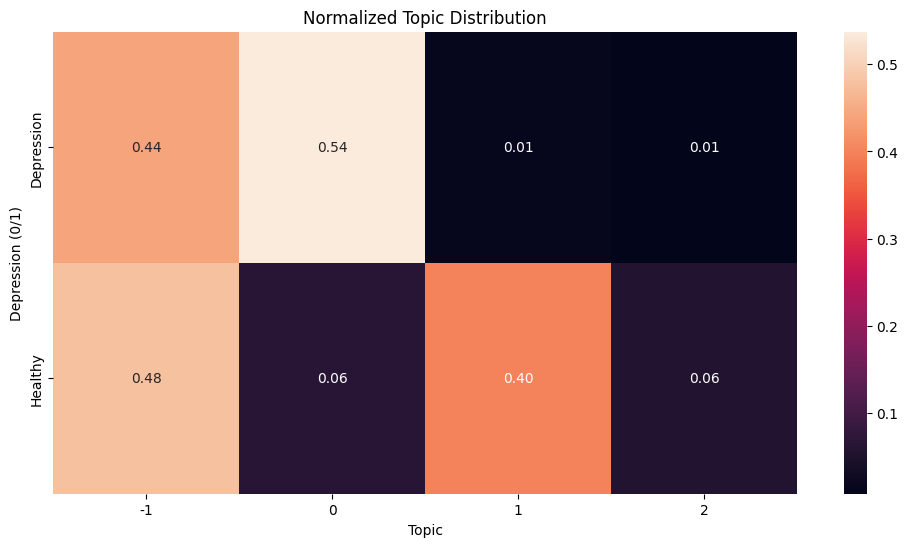

In [56]:
df_blog_depression_tokens_redux['bertopic'] = blog_model_red.topics_
df_blog_depression_tokens_redux['is_depression'] = df_blog_depression_tokens_redux['topic'].apply(lambda x: x if x == "Depression" else "Healthy")
ct = pd.crosstab(df_blog_depression_tokens_redux['is_depression'], df_blog_depression_tokens_redux['bertopic'])

import matplotlib.pyplot as plt
import seaborn as sns
ct_norm = ct.div(ct.sum(axis=1), axis=0)

plt.figure(figsize=(12,6))
sns.heatmap(ct_norm, annot=True, fmt='.2f')
plt.xlabel("Topic")
plt.ylabel("Depression (0/1)")
plt.title("Normalized Topic Distribution")
plt.show()

## Analiza Sentymentów

**Analiza Sentymentów** - To wykorzystanie procesowania języka naturalnego celem zdobcia informacji o stanach afektywnych. W najbardziej podstawowej wersji, sentiment analysis jest po prostu określeniem walencji: pozytywne vs negatywne (czasem neutralne)

Istnieje wiele metod i tego jak można przeprowadzić analizę sentymentów. Najprostsze opierają się na zliczaniu wystąpień słów nacechowanych emocjonalnie

Trudniejsze, są w stanie reprezentować 


Ładowanie danych ze zbioru Essays. 

In [57]:
### Get essay data

df_essays['lemmas'] = df_essays_token.groupby('post_id')['lemma'].apply(list)
df_essays

,O,C,E,A,N,ptype,text,__index_level_0__,lemmas
0,1,0,0,1,1,19,it is wednesday. I can't wait until friday bec...,774,"[it, i, wait, i, go, home, i, miss, he, i, wai..."
1,1,1,1,0,1,29,"wow, I want to go talk to the socialist organi...",178,"[i, want, talk, socialist, organization, they,..."
2,1,0,1,1,0,22,"I wish polygamy was still legal. Well, not pol...",1881,"[i, wish, polygamy, legal, polygamy, i, wish, ..."
3,1,0,1,0,0,20,"Well, lets see . . . I guess the foremost thin...",1563,"[let, i, guess, foremost, thing, i, my, mind, ..."
4,0,1,0,1,1,11,College? I wonder how it will be? I just ...,1594,"[i, wonder, it, i, start, it, it, nice, easy, ..."
...,...,...,...,...,...,...,...,...,...
1573,1,0,1,0,1,21,I am really hungry right now. I think I'l...,1519,"[i, hungry, right, i, think, i, eat, lunch, mi..."
1574,0,0,0,0,1,1,email is such a pain I cannot anxwer them fast...,658,"[email, pain, i, anxwer, they, fast, i, like, ..."
1575,0,1,0,0,1,9,I'm home. wanted to go to bed but remembe...,2462,"[i, home, want, bed, remember, i, psychology, ..."
1576,1,0,1,1,0,22,I'm not really sure what exactly I'm suppos...,1736,"[i, sure, what, exactly, i, suppose, there, gu..."


### TextBlob

TextBLob to biblioteka do prostych zastosowań NLP oparta w dużej mierze na NLTK. Posiada kilka własnych metod w tym własny Sentiment Analyzer. Opiera się on na prostym leksykonie i oznaczeniu emocjonalnym słów. Ma niestety spore problemy z mieszaniem sentymentów w zdaniu oraz kontekstem, sarkazmem i ironią.

Oparty jest o Naive Bayes Classifier : który estymuje na podstawie częstosci słów w danej klasie w danych treningowych prawdopodobieństwo warunkowe Klasy pod warunkiem słów w dokumencie

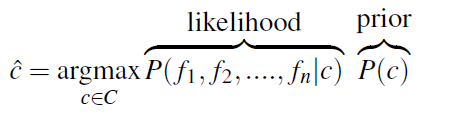


In [58]:
from textblob import TextBlob

## df of lemmas
df_essays['sentiment'] = df_essays['lemmas'].apply(lambda x: TextBlob(" ".join([str(i) for i in x])).sentiment.polarity)
df_essays

,O,C,E,A,N,ptype,text,__index_level_0__,lemmas,sentiment
0,1,0,0,1,1,19,it is wednesday. I can't wait until friday bec...,774,"[it, i, wait, i, go, home, i, miss, he, i, wai...",-0.052550
1,1,1,1,0,1,29,"wow, I want to go talk to the socialist organi...",178,"[i, want, talk, socialist, organization, they,...",-0.004534
2,1,0,1,1,0,22,"I wish polygamy was still legal. Well, not pol...",1881,"[i, wish, polygamy, legal, polygamy, i, wish, ...",0.102135
3,1,0,1,0,0,20,"Well, lets see . . . I guess the foremost thin...",1563,"[let, i, guess, foremost, thing, i, my, mind, ...",0.184855
4,0,1,0,1,1,11,College? I wonder how it will be? I just ...,1594,"[i, wonder, it, i, start, it, it, nice, easy, ...",0.081014
...,...,...,...,...,...,...,...,...,...,...
1573,1,0,1,0,1,21,I am really hungry right now. I think I'l...,1519,"[i, hungry, right, i, think, i, eat, lunch, mi...",-0.005272
1574,0,0,0,0,1,1,email is such a pain I cannot anxwer them fast...,658,"[email, pain, i, anxwer, they, fast, i, like, ...",0.169113
1575,0,1,0,0,1,9,I'm home. wanted to go to bed but remembe...,2462,"[i, home, want, bed, remember, i, psychology, ...",0.146003
1576,1,0,1,1,0,22,I'm not really sure what exactly I'm suppos...,1736,"[i, sure, what, exactly, i, suppose, there, gu...",0.201119


      sentiment          
           mean       std
O E N                    
0 0 0  0.090472  0.104592
    1  0.071142  0.108756
  1 0  0.094486  0.107024
    1  0.074868  0.118914
1 0 0  0.088156  0.106367
    1  0.067215  0.107452
  1 0  0.086983  0.097221
    1  0.066040  0.099416


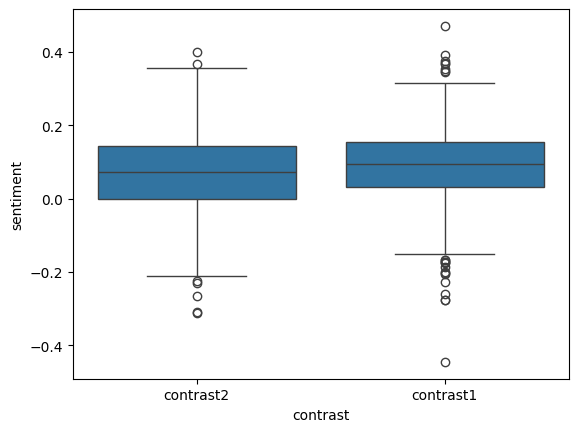

                            OLS Regression Results                            
Dep. Variable:              sentiment   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     14.44
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           0.000150
Time:                        11:34:40   Log-Likelihood:                 1308.1
No. Observations:                1578   AIC:                            -2612.
Df Residuals:                    1576   BIC:                            -2602.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.08

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import numpy as np
print(df_essays[['O','C','E','A','N','sentiment']].groupby(['O','E','N'])[['sentiment']].agg(['mean','std']))

contrast1 = (df_essays['N'] == '0') # & (df_essays['O'] == '0')
contrast2 = (df_essays['N'] == '1') # & (df_essays['O'] == '1')

df_essays['contrast'] = np.where(contrast1, 'contrast1',
                                 np.where(contrast2, 'contrast2', np.nan))


# stwórz kolumnę grupującą


sns.boxplot(x='contrast', y='sentiment', data=df_essays[contrast1 | contrast2])
plt.show()
model =  smf.ols('sentiment ~ contrast', data=df_essays[contrast1 | contrast2]).fit()
print(model.summary())

In [60]:
import textwrap


cond =  df_essays['N'] == df_essays['N'] #df_essays['N'] == '0'
negative = True;
for t in df_essays[cond].sort_values('sentiment',ascending=negative).head(5).index:
    print(f"\nSentiment: {df_essays.loc[t]['sentiment']} |  O:{df_essays.loc[t]['O']}  C:{df_essays.loc[t]['C']}  E:{df_essays.loc[t]['E']}  A:{df_essays.loc[t]['A']}  N:{df_essays.loc[t]['N']} | ID: {t}")
    print(textwrap.fill(df_essays.loc[t]['text']))


Sentiment: -0.445 |  O:1  C:1  E:1  A:1  N:0 | ID: 942
My roommate won't shut up. O. K. Bert. My friend Bert was just talking
to me. I better drop my Geography, because that class is boring. I
don't even read  the book because it's so boring. I hope I can drop it
before the date where I  get a full refund. My Dad might get mad, but
oh well. I think I'll go home  this weekend and work for my Dad
because I need some money. I hope he's working. My hand hurts already.
I can't study here. I can't wait until I get home. Sometimes I just
love being by myself. Man, my friend Matt needs to get a job. It's
like I'm running a daycare center. He's always at my house and he
never goes to school. He just plays on my Playstation all day.

Sentiment: -0.3109977324263039 |  O:1  C:0  E:0  A:0  N:1 | ID: 1015
I'm dizzy. This sucks and I feel worthless. How can she do that? I
probably look stupid standing here at this window. Damnit! I can't get
this song outta my head wish I could play it better fuckin

### Analiza sentymentów dla Blogów

przyjrzymy się teraz czy blogi odnośnie depresji vs blogi odnośnie innego tematu różnią się pod względem sentymentu

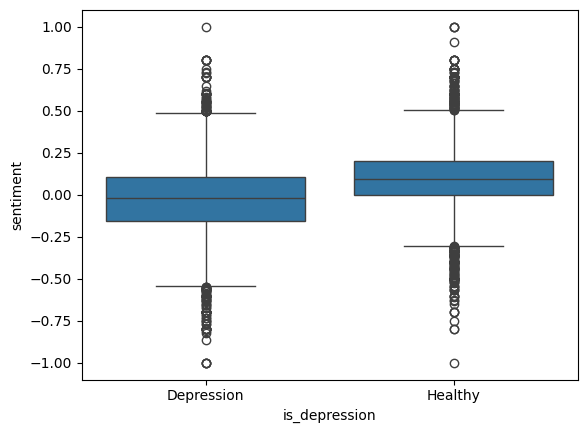

                            OLS Regression Results                            
Dep. Variable:              sentiment   R-squared:                       0.083
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     897.5
Date:                Thu, 09 Apr 2026   Prob (F-statistic):          7.07e-189
Time:                        11:34:42   Log-Likelihood:                 1534.0
No. Observations:                9958   AIC:                            -3064.
Df Residuals:                    9956   BIC:                            -3049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [61]:
import seaborn as sns
df_blog_depression_tokens_redux['is_depression'] = df_blog_depression_tokens_redux['topic'].apply(lambda x: x if x == "Depression" else "Healthy")
df_blog_depression_tokens_redux['sentiment'] = df_blog_depression_tokens_redux['lemma'].apply(lambda x: TextBlob(" ".join([str(i) for i in x])).sentiment.polarity)

sns.boxplot(x='is_depression', y='sentiment', data=df_blog_depression_tokens_redux)

plt.show()

model =  smf.ols('sentiment ~ is_depression', data=df_blog_depression_tokens_redux).fit()
print(model.summary())

In [62]:
import textwrap

currentClass = 'Depression' # 'Healthy
negative_con = False; # True - pozytywne, False - negatywne
depressed_positive =  df_blog_depression_tokens_redux[df_blog_depression_tokens_redux['is_depression']==currentClass].sort_values(by='sentiment',ascending=negative_con)[['text','sentiment']].head(4)

for t in depressed_positive.index:
    print(f"\nSentiment: {depressed_positive.loc[t]['sentiment']} | ID: {t}")
    print(textwrap.fill(depressed_positive.loc[t]['text']))


Sentiment: 1.0 | ID: 1800
Depression hit me today. I can't stop crying and getting out of bed is
a task on it's own.  I feel drained and I don't know what to do to
help it...especially when all my happy brain chemicals are gone.
What helps?

Sentiment: 0.8 | ID: 3901
I have tried everything. Just need something that takes over and I
appear happy to them, I’m 34 and they are the only people in my life.
Once they die at least semi-content it won’t matter anymore.

Sentiment: 0.8 | ID: 227
M 19. No matter who you are. I just need someone to talk to. I feel
like I can’t talk to anyone about what’s going on. I just need to feel
like someone cares. And I’m more than happy to  listen to whoever
messages me and help with whatever you need to talk about <3

Sentiment: 0.8 | ID: 3049
In a relationship I want a girl that is “broken” like me. I might have
my problems but I feel like I could be a great boyfriend if I tried.
I’d be there for her because I know what it’s like and she’d be there
for 

### BERT- sentiment

Poprzednie zadanie pokazywało jasno, że choć taki prosty klasyfikator jest w stanie skutecznie zobrazować przewidywane przez nas zależności między treścią i sentymentem, niestety w granicznych przypadkach sobie zupełnie nie radzi

Dzieje się tak przez założenia modelu Naiwnego Bayesa - że prawdopodobieństwa słów są niezależne: to nie jest prawda, ponieważ kontekst będzie znaczącą modulował nam znaczenie

Możemy więc zastosować już pełnoprawne modele językowe. Skorzystamy z gotowego klasyfikatora opartego o architekturę BERT

modele typu BERT składają się zazwyczaj z dwóch łatwo wymiennych części:
1. Tokenizier - zamiana słów i zdań na token złożone z podsłów
2. model - włąściwy model przeprowadzający Embedding i ewentualnie klasyfikację


Modele typu BERT zazwyczaj posiadają jasne ograncizenia co do ilości tokenów i nie przetworzą zapytania złożonego z ich większej ilości. Dlatego musimy poiciąć nasz tekst na drobniejsze lementy



In [ ]:

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

model_name = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)


def chunk_text_tokens(text, tokenizer, max_length=512, stride=50):
    inputs = tokenizer(
        text,
        return_overflowing_tokens=True,
        truncation=True,
        max_length=max_length,
        stride=stride
    )
    
    chunks = [
        tokenizer.decode(chunk, skip_special_tokens=True)
        for chunk in inputs['input_ids']
    ]
    
    return chunks

def sentiment_score(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True)
    outputs = model(**inputs)
    scores = torch.nn.functional.softmax(outputs.logits, dim=-1)
    return scores.detach().numpy()[0]


def sentiment_simple(text, tokenizer):
    chunks = chunk_text_tokens(text, tokenizer)
    scores = [sentiment_score(c) for c in chunks]
    return np.mean(scores, axis=0)


aaa = df_blog_depression_tokens_redux['text'].apply(lambda t: sentiment_simple(t,tokenizer));
df_blog_depression_sentiment = df_blog_depression_tokens_redux.copy()
df_blog_depression_sentiment['sentiment'] = aaa.tolist()

## 

In [ ]:
# df_blog_depression_all[['neg','neu','pos']] = aaa.to_list()
# df_blog_depression_all['is_depression'] = df_blog_depression_all['topic'].apply(lambda x: x if x == "Depression" else "Healthy")
# df_blog_depression_all.to_csv('blog_depression_sentiment.csv')

df_blog_depression_sentiment = pd.read_csv('data/blog_depression_sentiment.csv')

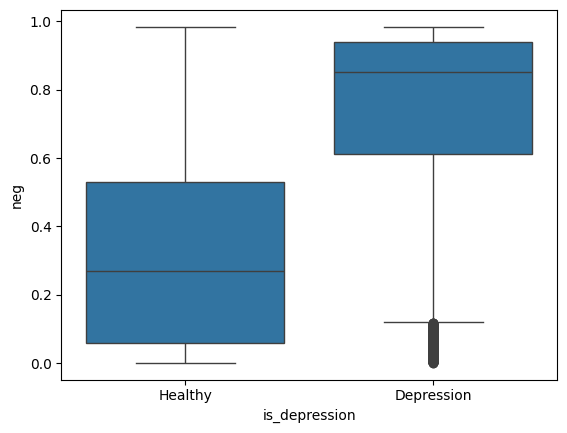



 ===== Healthy | neg ======

== Negative prob: 0.9838 | Neutral prob: 0.0134 | Positive prob: 0.0028| ID: 4966
So it's Saturday morning and I'm going to be going to hockey soon. But
something bugs me. I never can really have a good day anymore. I mean,
I can have a good game, but then I'll fall apart. I HATE It! It bugs
me sooooo much! Is it because I lose confidence? Is it because I get
tired? How will i ever make it to the next level when I'm going
backwards! ARGH!

== Negative prob: 0.9828 | Neutral prob: 0.0146 | Positive prob: 0.0025| ID: 6418
I just got home from seeing it.  This movie deserves no more than 1 or
2 paragraphs to be spoken about it.  Without futher ado(originally
posted by myself on cloudchaser.com):  Thank you Fox for finally
killing off any hope for future aliens and predator movies.  This pile
of shit was one of the worst movies I've ever seen.  There really
isn't that much alien on predator violence, the acting was terrible,
the story a joke, the characters w

In [64]:
import textwrap
import seaborn as sns

TextType = 'Healthy' # Depression / Healthy
Sentiment = 'neg'       # neg / neu / pos
df_blog_depression_sentiment['is_depression'] = df_blog_depression_sentiment['topic'].apply(lambda x: x if x == "Depression" else "Healthy")

sns.boxplot(x='is_depression', y=Sentiment, data=df_blog_depression_sentiment)

plt.show()

depressed_positive =  df_blog_depression_sentiment[df_blog_depression_sentiment['is_depression']==TextType].sort_values(by=Sentiment,ascending=False)[['text','neg','neu','pos']].head(4)
print(f"\n\n ===== {TextType} | {Sentiment} ======")
for t in depressed_positive.index:
    print(f"\n== Negative prob: {depressed_positive.loc[t]['neg']:1.4f} | Neutral prob: {depressed_positive.loc[t]['neu']:1.4f} | Positive prob: {depressed_positive.loc[t]['pos']:1.4f}| ID: {t}")
    print(textwrap.fill(depressed_positive.loc[t]['text']))

In [65]:

model =  smf.ols(f'{Sentiment} ~ is_depression', data=df_blog_depression_sentiment).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    neg   R-squared:                       0.340
Model:                            OLS   Adj. R-squared:                  0.340
Method:                 Least Squares   F-statistic:                     5119.
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:34:43   Log-Likelihood:                -1523.6
No. Observations:                9957   AIC:                             3051.
Df Residuals:                    9955   BIC:                             3066.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               